# Zebrafish hematopoiesis: database-mapped growth × moscot × GraphVelo

This notebook implements a native-moscot transport workflow:

- **M0** — uniform-marginal moscot baseline;
- **M1** — the primary zebrafish growth-informed moscot model using proliferation/apoptosis scores;
- **GraphVelo validation** — an independent comparison with the displacement implied by the native M1 coupling.

Human symbols are never passed to the zebrafish expression matrix. The growth panel
starts from human cell-cycle or directionally pro-death genes supported by Seurat/Tirosh,
KEGG, and/or Reactome, then requires a ZFIN human–zebrafish orthology record and presence
in the zebrafish gene universe. The frozen expanded table contains 95 zebrafish
proliferation genes (91 human genes) and 46 zebrafish apoptosis genes (38 human genes).
The notebook further requires expression detection in the cells actually analyzed.

The full KEGG/Reactome apoptosis pathways are deliberately **not** treated as a single
death score: they contain anti-apoptotic and survival genes. Only a directionally curated
pro-death subset is used for the apoptosis marginal.

**No fixed Top-50 truncation is used in this version.** Every positive entry returned by
the moscot solver is retained. Because entropic OT can be dense, cell-level edge tables
are not exported by default.

Run the notebook from top to bottom. M0→M1 isolates the contribution of growth.
GraphVelo never changes the coupling; it is used for independent directional concordance.

## Equations and interpretation

For source cell $i$ and target cell $j$, moscot returns a raw coupling
$P^{\mathrm{raw}}_{ij}$. Its source-row mass is

$$
g_i = \sum_j P^{\mathrm{raw}}_{ij}.
$$

Conditional fate probabilities are

$$
P^{\mathrm{cond}}_{ij} = \frac{P^{\mathrm{raw}}_{ij}}{g_i}.
$$

The moscot conditional barycenter and implied displacement velocity are

$$
\bar X_i^{\mathrm{moscot}} = \sum_j P^{\mathrm{cond}}_{ij}X_j,
\qquad
V_i^{\mathrm{moscot}} = \frac{\bar X_i^{\mathrm{moscot}}-X_i}{\Delta t}.
$$

GraphVelo is compared with this displacement without modifying the transport:

$$
c_i = \frac{V_i^{\mathrm{GraphVelo}} \cdot V_i^{\mathrm{moscot}}}
{\lVert V_i^{\mathrm{GraphVelo}}\rVert_2
 \lVert V_i^{\mathrm{moscot}}\rVert_2}.
$$

`raw` mass answers **how much** is transported; `cond` answers **where it goes,
conditional on being transported**. Cosine concordance, transport dispersion,
within-time permutation tests, and fish-level bootstrap intervals are reported.

Method references: [moscot growth marginals](https://moscot.readthedocs.io/en/latest/notebooks/examples/problems/TemporalProblem/800_score_genes_for_marginals.html),
[moscot paper](https://www.nature.com/articles/s41586-024-08453-2), and
[GraphVelo paper](https://www.nature.com/articles/s41467-025-62784-w).

Marker references: [Seurat cell-cycle genes](https://satijalab.org/seurat/reference/cc.genes.updated.2019.html),
[Tirosh et al. 2016](https://doi.org/10.1126/science.aad0501),
[KEGG cell cycle](https://www.kegg.jp/pathway/hsa04110),
[KEGG apoptosis](https://www.kegg.jp/pathway/hsa04210),
[Reactome mitotic cell cycle](https://reactome.org/content/detail/R-HSA-69278),
[Reactome apoptosis](https://reactome.org/content/detail/R-HSA-109581), and
[ZFIN human orthology download](https://zfin.org/downloads/human_orthos.txt).

## 0. Configuration

Edit the two paths only if your filenames differ. `INPUT_H5AD` supplies expression,
`spliced`, and `unspliced`. `LINEAGE_H5AD` supplies official fine annotations,
experimental timepoint, and fish. The objects are joined only by exact cell IDs.

The official ZEBRAHUB file is
`zf_atlas_hematopoetic_endothelial_v4_release.h5ad` (206.6 MB). If it was downloaded
as `~/dynamo/Lineage.h5ad`, the configuration below works unchanged.


In [1]:
import os
from pathlib import Path

# Numba and Matplotlib otherwise try to write into unavailable home cache paths
# on compute nodes, which can make imports fail before the analysis starts.
RUNTIME_CACHE_ROOT = Path("/tmp") / f"zebrafish_growth_{os.getuid()}"
for cache_name in ("numba", "matplotlib", "xdg"):
    (RUNTIME_CACHE_ROOT / cache_name).mkdir(parents=True, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", str(RUNTIME_CACHE_ROOT / "numba"))
os.environ.setdefault("MPLCONFIGDIR", str(RUNTIME_CACHE_ROOT / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(RUNTIME_CACHE_ROOT / "xdg"))

import platform
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from IPython.display import display

SEED = 0
np.random.seed(SEED)

# path
PROJECT_DIR = Path.home() / "dynamo" / "blood_growth_graphvelo_moscot_v2"
INPUT_H5AD = Path.home() / "dynamo" / "zebrahub_full_velocity.h5ad"
LINEAGE_H5AD = Path.home() / "dynamo" / "lineage.h5ad"
FULL_EXPRESSION_H5AD = (
    Path.home() / "dynamo" / "zf_atlas_hematopoetic_endothelial_v4_release.h5ad"
)

# These are official lineage.obs columns, not names invented in this notebook.
LINEAGE_ANNOTATION_COL = "annotation"
LINEAGE_TIMEPOINT_COL = "timepoint"

# Optional: after reviewing the official inventory, list exact official labels to model.
# None means use every official label with enough cells.
MODEL_FINE_LABELS = None

RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURE_DIR = RESULTS_DIR / "figures"
for path in (RESULTS_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    path.mkdir(parents=True, exist_ok=True)

N_HVG = 2000
N_PCS = 50
N_NEIGHBORS = 30
# Keep ODE interpolation local and consistent with the 30-neighbor cell graph.
ODE_K_NEIGHBORS = 30
MIN_CELLS_PER_FINE_TYPE = 30
TIME_TOLERANCE_HPF = 3.0

print("Python:", platform.python_version())
print("AnnData:", ad.__version__)
print("Scanpy:", sc.__version__)
print("SciPy:", scipy.__version__)
print("Velocity input:", INPUT_H5AD)
print("Official lineage input:", LINEAGE_H5AD)
print("Full-gene scoring input:", FULL_EXPRESSION_H5AD)


Python: 3.11.15
AnnData: 0.10.9
Scanpy: 1.11.5
SciPy: 1.16.3
Velocity input: /net/dali/home/mscbio/jis322/dynamo/zebrahub_full_velocity.h5ad
Official lineage input: /net/dali/home/mscbio/jis322/dynamo/lineage.h5ad
Full-gene scoring input: /net/dali/home/mscbio/jis322/dynamo/zf_atlas_hematopoetic_endothelial_v4_release.h5ad


/tmp/ipykernel_3221629/4213187483.py:62: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 1. Source audit and annotation provenance

The notebook independently opens the velocity and official lineage objects. It requires
raw splicing layers and literal official annotation/timepoint columns. Existing PCA,
UMAP, neighbors, velocities, and manually created names are ignored.


In [2]:
# Fail early with an informative path if either required file is absent.
assert INPUT_H5AD.exists(), f"Velocity file not found: {INPUT_H5AD}"
assert LINEAGE_H5AD.exists(), f"Lineage file not found: {LINEAGE_H5AD}"
assert FULL_EXPRESSION_H5AD.exists(), (
    f"Full-gene scoring file not found: {FULL_EXPRESSION_H5AD}"
)

# Backed mode avoids loading the 21-GB velocity object fully into RAM.
source = ad.read_h5ad(INPUT_H5AD, backed="r")
lineage = ad.read_h5ad(LINEAGE_H5AD, backed="r")

assert source.obs_names.is_unique, "Velocity cell IDs are not unique."
assert lineage.obs_names.is_unique, "Lineage cell IDs are not unique."
assert {"spliced", "unspliced"}.issubset(source.layers.keys())
assert LINEAGE_ANNOTATION_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_ANNOTATION_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)
assert LINEAGE_TIMEPOINT_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_TIMEPOINT_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)

print("Velocity shape:", source.shape)
print("Lineage shape:", lineage.shape)
print("Velocity raw layers:", list(source.layers.keys()))
print("Existing velocity obsm (ignored):", list(source.obsm.keys()))
print("Official fine annotation column:", LINEAGE_ANNOTATION_COL)
display(lineage.obs[LINEAGE_ANNOTATION_COL].value_counts(dropna=False))


Velocity shape: (120800, 3000)
Lineage shape: (5441, 27435)
Velocity raw layers: ['Ms', 'Mu', 'counts', 'fit_t', 'fit_tau', 'fit_tau_', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity', 'velocity_u']
Existing velocity obsm (ignored): ['X_pca', 'X_umap', 'velocity_umap']
Official fine annotation column: annotation


annotation
erythroblast                              2358
macrophage                                 817
hematopoietic_stem_and_progenitor_HSPC     655
neutrophil                                 507
non_specific_hematopoietic                 464
macrophage_immature                        319
microglia                                  193
innate-lymphoid-cell                       113
thymocyte                                   15
Name: count, dtype: int64

## 2. Exact cell-ID alignment with the official lineage object

Only exact shared cell IDs are used. `official_fine_cell_type` is copied directly from
`lineage.obs["annotation"]`. Numeric clusters never participate in naming.


In [3]:
def first_existing(columns, candidates, required=True):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    if required:
        raise KeyError(f"None of these columns exists: {candidates}")
    return None

# Fish is taken from official lineage metadata. Cluster is optional audit metadata.
FISH_COL = first_existing(lineage.obs.columns, ["fish", "official_fish"])
CLUSTER_COL = first_existing(
    source.obs.columns, ["clusters", "seurat_clusters"], required=False
)

# Preserve velocity-object order; do not fuzzy-match or match by cluster.
candidate_ids = source.obs_names[source.obs_names.isin(lineage.obs_names)]
official_fine = lineage.obs[LINEAGE_ANNOTATION_COL].reindex(candidate_ids)
official_timepoint = lineage.obs[LINEAGE_TIMEPOINT_COL].reindex(candidate_ids)
official_fish = lineage.obs[FISH_COL].reindex(candidate_ids)

merge_audit = pd.Series({
    "velocity_cells": source.n_obs,
    "lineage_cells": lineage.n_obs,
    "exact_shared_cell_ids": len(candidate_ids),
    "lineage_match_fraction": len(candidate_ids) / lineage.n_obs,
    "missing_fine_annotation": int(official_fine.isna().sum()),
    "missing_timepoint": int(official_timepoint.isna().sum()),
    "missing_fish": int(official_fish.isna().sum()),
}, name="n_cells")
display(merge_audit)

assert len(candidate_ids) > 0, "No exact shared cell IDs between velocity and lineage."
assert official_fine.notna().all()
assert official_timepoint.notna().all()
assert official_fish.notna().all()
assert official_fine.astype(str).str.strip().ne("").all(), "Blank official labels found."

print("Official fine labels:")
display(official_fine.value_counts().rename("n_cells").to_frame())


velocity_cells             120800.0
lineage_cells                5441.0
exact_shared_cell_ids        5441.0
lineage_match_fraction          1.0
missing_fine_annotation         0.0
missing_timepoint               0.0
missing_fish                    0.0
Name: n_cells, dtype: float64

Official fine labels:


,n_cells
annotation,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 3. Official fine-annotation inventory

The inventory reports official biological labels against hpf, fish, and numeric cluster.
The cluster column is included only to audit heterogeneity; it never determines a name.


In [4]:
# Start from velocity metadata so cluster values remain available for QC only.
audit_obs = source.obs.loc[candidate_ids].copy()

# Add official metadata by exact cell-ID alignment. These assignments do not use row
# position, cluster number, keywords, or a hand-written biological naming dictionary.
audit_obs["official_fine_cell_type"] = official_fine.reindex(
    audit_obs.index
).to_numpy()
audit_obs["timepoint"] = official_timepoint.reindex(audit_obs.index).to_numpy()
audit_obs["fish_id"] = official_fish.reindex(audit_obs.index).astype(str).to_numpy()
audit_obs["cluster_label"] = (
    audit_obs[CLUSTER_COL].astype(str) if CLUSTER_COL is not None else "not_available"
)

# Parse experimental time labels such as 16hpf, 2dpf, and 10dpf.
# This is a unit conversion, not pseudotime and not a biological label mapping.
timepoint_text = audit_obs["timepoint"].astype("string").str.strip().str.lower()
parsed_timepoint = timepoint_text.str.extract(
    r"^(?P<number>\d+(?:\.\d+)?)(?P<unit>hpf|dpf)$"
)
parsed_number = pd.to_numeric(parsed_timepoint["number"], errors="coerce")

# Convert days post fertilization into hours post fertilization: 1 dpf = 24 hpf.
audit_obs["hpf_numeric"] = np.where(
    parsed_timepoint["unit"].eq("dpf"),
    parsed_number * 24.0,
    parsed_number,
)
audit_obs["hpf_numeric"] = pd.to_numeric(
    audit_obs["hpf_numeric"], errors="coerce"
)

# Show the conversion table before asserting, so any unsupported value is visible.
timepoint_conversion_audit = (
    audit_obs[["timepoint", "hpf_numeric"]]
    .drop_duplicates()
    .sort_values("hpf_numeric")
)
display(timepoint_conversion_audit)

failed_timepoints = (
    audit_obs.loc[audit_obs["hpf_numeric"].isna(), "timepoint"]
    .value_counts(dropna=False)
)
if len(failed_timepoints):
    display(failed_timepoints.rename("n_failed_cells").to_frame())

# Assertions belong after parsing and diagnostics—not before hpf_numeric exists.
assert audit_obs["official_fine_cell_type"].notna().all(), (
    "Some shared cells lack lineage.obs['annotation']."
)
assert audit_obs["hpf_numeric"].notna().all(), (
    "Some lineage timepoint values could not be converted to hpf:\n"
    f"{failed_timepoints.to_string()}"
)

inventory = (
    audit_obs.groupby(
        ["official_fine_cell_type", "hpf_numeric", "cluster_label"],
        dropna=False, observed=True,
    )
    .agg(n_cells=("fish_id", "size"), n_fish=("fish_id", "nunique"))
    .reset_index()
    .sort_values(["official_fine_cell_type", "hpf_numeric", "n_cells"],
                 ascending=[True, True, False])
)
inventory.to_csv(RESULTS_DIR / "official_fine_annotation_inventory.csv", index=False)
display(inventory)


,timepoint,hpf_numeric
cell_id,,
TDR36_GGAGATGAGAAGGCTC-1,12hpf,12.0
TDR22_GGGTCACCAGCGCGTT-1,14hpf,14.0
TDR42_GAGTTTGCAACTCGAT-1,16hpf,16.0
TDR27_GTCTACCTCATTGCTT-1,19hpf,19.0
TDR46_GTGTCCTAGGATATAC-1,24hpf,24.0
TDR48_TATCCTAAGCGTATGG-1,2dpf,48.0
TDR68_CTGTGAAAGTGCTACT-1,3dpf,72.0
TDR51_TCATCCGCAACCTATG-1,5dpf,120.0
TDR74_TCACACCAGAGTTCGG-1,10dpf,240.0


,official_fine_cell_type,hpf_numeric,cluster_label,n_cells,n_fish
0,erythroblast,12.0,39,6,2
1,erythroblast,14.0,23,32,4
2,erythroblast,14.0,24,1,1
3,erythroblast,14.0,35,1,1
4,erythroblast,16.0,23,102,4
...,...,...,...,...,...
132,non_specific_hematopoietic,240.0,23,2,1
134,non_specific_hematopoietic,240.0,35,1,1
135,non_specific_hematopoietic,240.0,39,1,1
136,thymocyte,120.0,24,1,1


In [5]:
fine_annotation_summary = (
    audit_obs.groupby("official_fine_cell_type", observed=True)
    .agg(
        n_cells=("fish_id", "size"),
        n_fish=("fish_id", "nunique"),
        first_hpf=("hpf_numeric", "min"),
        last_hpf=("hpf_numeric", "max"),
        n_numeric_clusters=("cluster_label", "nunique"),
    )
    .sort_values("n_cells", ascending=False)
)
display(fine_annotation_summary)
fine_annotation_summary.to_csv(RESULTS_DIR / "official_fine_annotation_summary.csv")

print("GATE 1 PASSED: names come directly from lineage.obs['annotation'].")
print("Review the complete inventory before running the modeling sections.")


,n_cells,n_fish,first_hpf,last_hpf,n_numeric_clusters
official_fine_cell_type,,,,,
erythroblast,2358,32,12.0,240.0,8
macrophage,817,30,14.0,240.0,3
hematopoietic_stem_and_progenitor_HSPC,655,28,14.0,240.0,4
neutrophil,507,21,16.0,240.0,3
non_specific_hematopoietic,464,33,12.0,240.0,8
macrophage_immature,319,31,12.0,240.0,7
microglia,193,16,12.0,240.0,3
innate-lymphoid-cell,113,10,24.0,240.0,2
thymocyte,15,5,120.0,240.0,1


GATE 1 PASSED: names come directly from lineage.obs['annotation'].
Review the complete inventory before running the modeling sections.


## 4. Build a fresh in-memory blood object

Only exact lineage-matched cells are copied. Raw spliced and unspliced matrices are
preserved, while inherited dimensional reductions and graphs are discarded.


In [6]:
# Avoid source[candidate_ids, :].to_memory(): it attempts to materialize every
# inherited obsm/obsp/layer in the 21-GB backed object. Read only the required
# matrices and metadata, preserving the exact candidate-ID order.
candidate_ids = pd.Index(candidate_ids).astype(str)
candidate_pos = source.obs_names.get_indexer(candidate_ids)
assert (candidate_pos >= 0).all(), "Some candidate IDs are absent from source."

selected_obs = source.obs.iloc[candidate_pos].copy()
selected_var = source.var.copy()
S = sp.csr_matrix(source.layers["spliced"][candidate_pos, :])
U = sp.csr_matrix(source.layers["unspliced"][candidate_pos, :])
assert selected_obs.index.equals(candidate_ids)
assert S.shape == U.shape == (len(candidate_ids), source.n_vars)

source.file.close()
lineage.file.close()
del source, lineage

counts = (S + U).tocsr()

blood_clean = ad.AnnData(
    X=counts.copy(), obs=selected_obs, var=selected_var
)
blood_clean.layers["counts"] = counts.copy()
blood_clean.layers["spliced"] = S.copy()
blood_clean.layers["unspliced"] = U.copy()

# Copy the already-audited metadata by exact cell ID.
# No cluster-number dictionary and no row-position-based assignment is used.
aligned_audit = audit_obs.reindex(blood_clean.obs_names)
blood_clean.obs["official_fine_cell_type"] = aligned_audit[
    "official_fine_cell_type"
].to_numpy()
blood_clean.obs["timepoint"] = aligned_audit["timepoint"].to_numpy()
blood_clean.obs["hpf"] = aligned_audit["hpf_numeric"].astype(float).to_numpy()
blood_clean.obs["fish_id"] = aligned_audit["fish_id"].astype(str).to_numpy()

gene_totals = np.asarray(counts.sum(axis=0)).ravel()
blood_clean = blood_clean[:, gene_totals > 0].copy()

assert blood_clean.obs_names.equals(pd.Index(candidate_ids))
assert blood_clean.obs["official_fine_cell_type"].notna().all()
assert blood_clean.obs["hpf"].notna().all()
assert blood_clean.obs_names.is_unique
print(blood_clean)


AnnData object with n_obs × n_vars = 5441 × 2986
    obs: 'clusters', 'seurat_clusters', 'timepoint', 'fish', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'official_fine_cell_type', 'hpf', 'fish_id'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2'
    layers: 'counts', 'spliced', 'unspliced'


## 5. Biological names remain official

There is deliberately no `SUBTYPE_RULES`, regex classifier, or cluster-name mapping.
The modeling label is an exact copy of `official_fine_cell_type`. If a broader lineage
grouping is later needed, create it as a separately sourced biological ontology table—
never by interpreting numeric cluster IDs.


In [7]:
blood_clean.obs["model_cell_type"] = pd.Categorical(
    blood_clean.obs["official_fine_cell_type"]
)

identity_check = pd.crosstab(
    blood_clean.obs["official_fine_cell_type"],
    blood_clean.obs["model_cell_type"],
)
display(identity_check)

off_diagonal = identity_check.to_numpy().sum() - np.trace(identity_check.to_numpy())
assert off_diagonal == 0, "Model labels differ from official fine annotations."

official_counts = blood_clean.obs["official_fine_cell_type"].value_counts()
display(official_counts.rename("n_cells").to_frame())
official_counts.rename("n_cells").to_csv(
    RESULTS_DIR / "official_fine_cell_type_counts.csv"
)


model_cell_type,erythroblast,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,macrophage,macrophage_immature,microglia,neutrophil,non_specific_hematopoietic,thymocyte
official_fine_cell_type,,,,,,,,,
erythroblast,2358,0,0,0,0,0,0,0,0
hematopoietic_stem_and_progenitor_HSPC,0,655,0,0,0,0,0,0,0
innate-lymphoid-cell,0,0,113,0,0,0,0,0,0
macrophage,0,0,0,817,0,0,0,0,0
macrophage_immature,0,0,0,0,319,0,0,0,0
microglia,0,0,0,0,0,193,0,0,0
neutrophil,0,0,0,0,0,0,507,0,0
non_specific_hematopoietic,0,0,0,0,0,0,0,464,0
thymocyte,0,0,0,0,0,0,0,0,15


,n_cells
official_fine_cell_type,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 6. Data-driven candidate-marker discovery without relabeling

No hand-written marker dictionary is used. Genes are ranked directly from the expression
data by comparing each official ZEBRAHUB class against the remaining classes. These are
data-derived candidate markers for QC, not independently validated biomarkers, and they
never assign or rename a cell.


,official_fine_cell_type,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
4,erythroblast,hbae1.3,54.996449,7.367101,0.000000e+00,0.000000e+00,0.963953,0.390204
5,erythroblast,hbbe1.3,54.145729,7.284439,0.000000e+00,0.000000e+00,0.962256,0.481674
0,erythroblast,hbae3,56.294945,7.270494,0.000000e+00,0.000000e+00,0.977947,0.615310
2,erythroblast,hbae1.3-1,55.458435,7.203584,0.000000e+00,0.000000e+00,0.929177,0.179046
1,erythroblast,hbbe1.1,56.293018,7.108180,0.000000e+00,0.000000e+00,0.968617,0.537464
...,...,...,...,...,...,...,...,...
23908,thymocyte,bcl11ba,5.398007,6.208471,6.738514e-08,9.581525e-06,0.866667,0.096203
23906,thymocyte,sat1a.1,5.549603,5.998657,2.863199e-08,4.499743e-06,0.866667,0.128824
23902,thymocyte,ncaldb,5.765391,5.537986,8.146870e-09,1.621770e-06,0.933333,0.207151
23893,thymocyte,laptm5,6.444031,5.461966,1.163416e-10,5.789933e-08,1.000000,0.485809


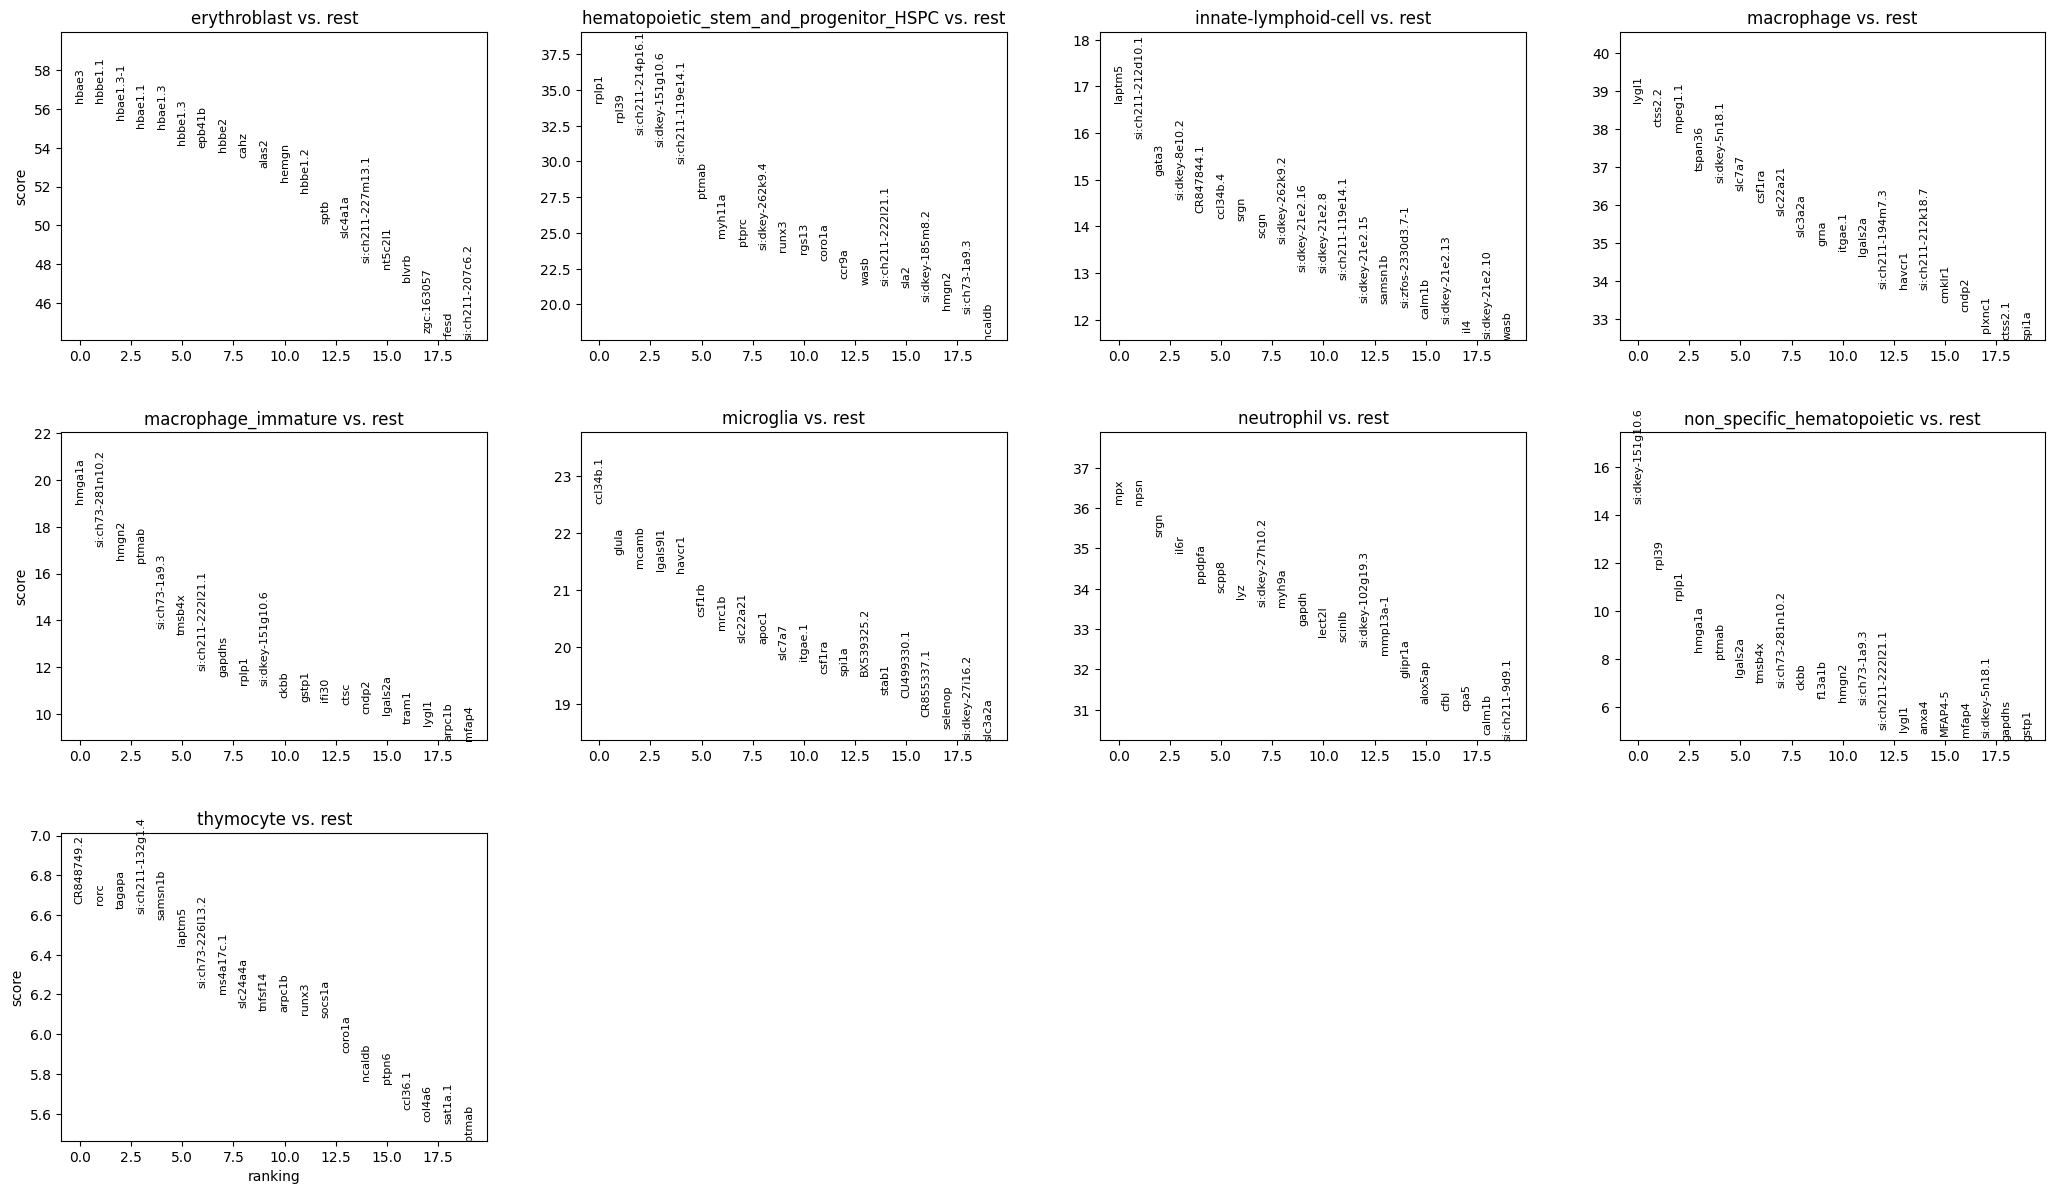

In [8]:
# EXPLORATORY ONLY: Scanpy's cell-level p-values below do not treat fish as independent replicates.
# Use the fish-aware pseudobulk results in the next cell for inference.
marker_data = blood_clean.copy()
marker_data.X = marker_data.layers["counts"].copy()
sc.pp.normalize_total(marker_data, target_sum=1e4)
sc.pp.log1p(marker_data)
marker_data.obs["official_fine_cell_type"] = marker_data.obs[
    "official_fine_cell_type"
].astype("category")

sc.tl.rank_genes_groups(
    marker_data,
    groupby="official_fine_cell_type",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
)

marker_tables = []
for official_label in marker_data.obs["official_fine_cell_type"].cat.categories:
    table = sc.get.rank_genes_groups_df(marker_data, group=official_label)
    table.insert(0, "official_fine_cell_type", str(official_label))
    marker_tables.append(table)

data_driven_markers = pd.concat(marker_tables, ignore_index=True)
candidate_markers = data_driven_markers.loc[
    data_driven_markers["pvals_adj"].lt(0.05)
    & data_driven_markers["logfoldchanges"].gt(1.0)
].copy()
candidate_markers = candidate_markers.sort_values(
    ["official_fine_cell_type", "logfoldchanges"],
    ascending=[True, False],
)
candidate_markers.to_csv(
    RESULTS_DIR / "exploratory_cell_level_candidate_markers.csv", index=False
)
top_candidate_markers = candidate_markers.groupby(
    "official_fine_cell_type", observed=True, group_keys=False
).head(20)
display(top_candidate_markers)

sc.pl.rank_genes_groups(
    marker_data, n_genes=20, sharey=False, show=False
)
plt.savefig(
    FIGURE_DIR / "exploratory_cell_level_candidate_markers.pdf",
    bbox_inches="tight",
)
plt.show()


### Fish-aware pseudobulk marker validation

The preceding Wilcoxon ranking is an exploratory visualization. The analysis below compares each cell type with the other cells from the same fish and hpf, then tests across fish. Fish—not individual cells—are therefore the independent replicates.


In [9]:
from fish_aware_marker_qc import run_fish_aware_marker_qc

fish_marker_qc = run_fish_aware_marker_qc(
    FULL_EXPRESSION_H5AD,
    blood_clean,
    RESULTS_DIR,
    min_target_cells=5,
    min_rest_cells=20,
    min_fish=3,
)
display(fish_marker_qc["summary"])
display(fish_marker_qc["top_candidates"])


,official_fine_cell_type,n_independent_fish,n_fish_time_contrasts,status,significant_positive_markers
0,erythroblast,21,21,tested,560
1,hematopoietic_stem_and_progenitor_HSPC,17,17,tested,319
2,innate-lymphoid-cell,7,7,tested,214
3,macrophage,21,21,tested,1507
4,macrophage_immature,15,15,tested,247
5,microglia,12,12,tested,752
6,neutrophil,14,14,tested,1080
7,non_specific_hematopoietic,23,23,tested,1
8,thymocyte,1,1,insufficient_fish,0


,official_fine_cell_type,gene,n_independent_fish,mean_within_fish_log2cpm_difference,sd_within_fish_log2cpm_difference,t_statistic,p_value,fdr_bh
5918,erythroblast,hbae1.3-1,21,6.592869,3.072457,9.833275,4.194345e-09,3.150964e-07
5919,erythroblast,hbae3,21,6.512328,3.182409,9.377560,9.218036e-09,5.308563e-07
5913,erythroblast,hbbe1.1,21,6.440722,3.189209,9.254678,1.144748e-08,6.219040e-07
5917,erythroblast,hbbe1.3,21,6.390757,3.157091,9.276300,1.101791e-08,6.030810e-07
5915,erythroblast,hbbe1.2,21,6.243561,3.348559,8.544448,4.153612e-08,1.722805e-06
...,...,...,...,...,...,...,...,...
175752,neutrophil,il6r,14,5.819834,0.929872,23.418078,5.144668e-12,5.268858e-09
166780,neutrophil,si:dkey-19b23.14,14,5.721773,0.697547,30.691717,1.621313e-13,5.294082e-10
178103,neutrophil,ppdpfa,14,5.714693,0.777982,27.484454,6.670592e-13,1.407752e-09
172965,neutrophil,BX908782.2,14,5.653832,3.779699,5.596928,8.669849e-05,1.751992e-03


In [10]:
type_time_fish = (
    blood_clean.obs.groupby(
        ["official_fine_cell_type", "hpf", "fish_id"], observed=True
    )
    .size().rename("n_cells").reset_index()
)
display(type_time_fish)
type_time_fish.to_csv(RESULTS_DIR / "official_type_time_fish_counts.csv", index=False)

eligible_labels = official_counts[
    official_counts >= MIN_CELLS_PER_FINE_TYPE
].index.astype(str).tolist()

if MODEL_FINE_LABELS is None:
    modeled_labels = eligible_labels
else:
    unknown = sorted(set(MODEL_FINE_LABELS) - set(official_counts.index.astype(str)))
    assert not unknown, f"Requested labels are not official annotations: {unknown}"
    too_small = sorted(set(MODEL_FINE_LABELS) - set(eligible_labels))
    assert not too_small, f"Requested labels have too few cells: {too_small}"
    modeled_labels = list(MODEL_FINE_LABELS)

assert len(modeled_labels) >= 2, "Fewer than two official fine types pass the count gate."
print("Official labels retained for modeling:", modeled_labels)
print("GATE 2: candidate markers were learned from data and never alter labels.")


,official_fine_cell_type,hpf,fish_id,n_cells
0,erythroblast,12.0,TDR35,1
1,erythroblast,12.0,TDR37,5
2,erythroblast,14.0,TDR18,17
3,erythroblast,14.0,TDR19,5
4,erythroblast,14.0,TDR21,3
...,...,...,...,...
201,thymocyte,120.0,TDR51,1
202,thymocyte,240.0,TDR71,4
203,thymocyte,240.0,TDR72,3
204,thymocyte,240.0,TDR73,2


Official labels retained for modeling: ['erythroblast', 'macrophage', 'hematopoietic_stem_and_progenitor_HSPC', 'neutrophil', 'non_specific_hematopoietic', 'macrophage_immature', 'microglia', 'innate-lymphoid-cell']
GATE 2: candidate markers were learned from data and never alter labels.


## 7. Restrict to official labels and run Dynamo preprocessing once

The working object begins from the clean raw-count subset. `recipe_monocle` performs
Dynamo's required normalization and feature selection once. We then compute the PCA
and 30-neighbor graph used by moments, dynamics, and GraphVelo. `blood_clean` remains
unchanged as the raw-count checkpoint. This preprocessing recipe does not mean that
Monocle pseudotime is used.


In [11]:
import dynamo as dyn

model_mask = blood_clean.obs["official_fine_cell_type"].isin(modeled_labels)
adata = blood_clean[model_mask].copy()
adata.obs["model_cell_type"] = pd.Categorical(
    adata.obs["official_fine_cell_type"]
)

# Explicitly start Dynamo from total raw counts.
adata.X = adata.layers["counts"].copy()
processed = dyn.pp.recipe_monocle(
    adata, n_top_genes=min(N_HVG, adata.n_vars)
)
if processed is not None:
    adata = processed

assert "use_for_pca" in adata.var.columns
assert adata.var["use_for_pca"].sum() > 0

# Recompute a deterministic PCA and the requested 30-neighbor graph on the
# Dynamo-preprocessed expression matrix.
sc.tl.pca(
    adata,
    n_comps=min(N_PCS, adata.n_vars - 1, adata.n_obs - 1),
    mask_var="use_for_pca",
    svd_solver="arpack",
    random_state=SEED,
)
sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=adata.obsm["X_pca"].shape[1],
    use_rep="X_pca",
    random_state=SEED,
)
print(adata)
print("PCA:", adata.obsm["X_pca"].shape)


|-----? dynamo.preprocessing.deprecated is deprecated.


|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True


|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True


|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True


|-----> apply Monocole recipe to adata...


...

|-----> computing cell phase...


|-----? 
Dynamo is not able to perform cell cycle staging for you automatically. 
Since dyn.pl.phase_diagram in dynamo by default colors cells by its cell-cycle stage, 
you need to set color argument accordingly if confronting errors related to this.


|-----> [recipe_monocle preprocess] completed [1.0504s]



╭─ SUMMARY: recipe_monocle ──────────────────────────────────────────╮
│  Duration: 1.055s                                                  │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ Size_Factor (float)                                  │
│           │ ✚ initial_cell_size (float)                            │
│           │ ✚ initial_spliced_cell_size (float)                    │
│           │ ✚ initial_unspliced_cell_size (float)                  │
│           │ ✚ nCounts (float)                                      │
│           │ ✚ nGenes (int)                                         │
│           │ ✚ ntr (float)                                          │
│           │ ✚ pMito (int)                                          │
│    

AnnData object with n_obs × n_vars = 5426 × 2986
    obs: 'clusters', 'seurat_clusters', 'timepoint', 'fish', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'official_fine_cell_type', 'hpf', 'fish_id', 'model_cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'ntr'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2', 'nCells', 'nCounts', 'p

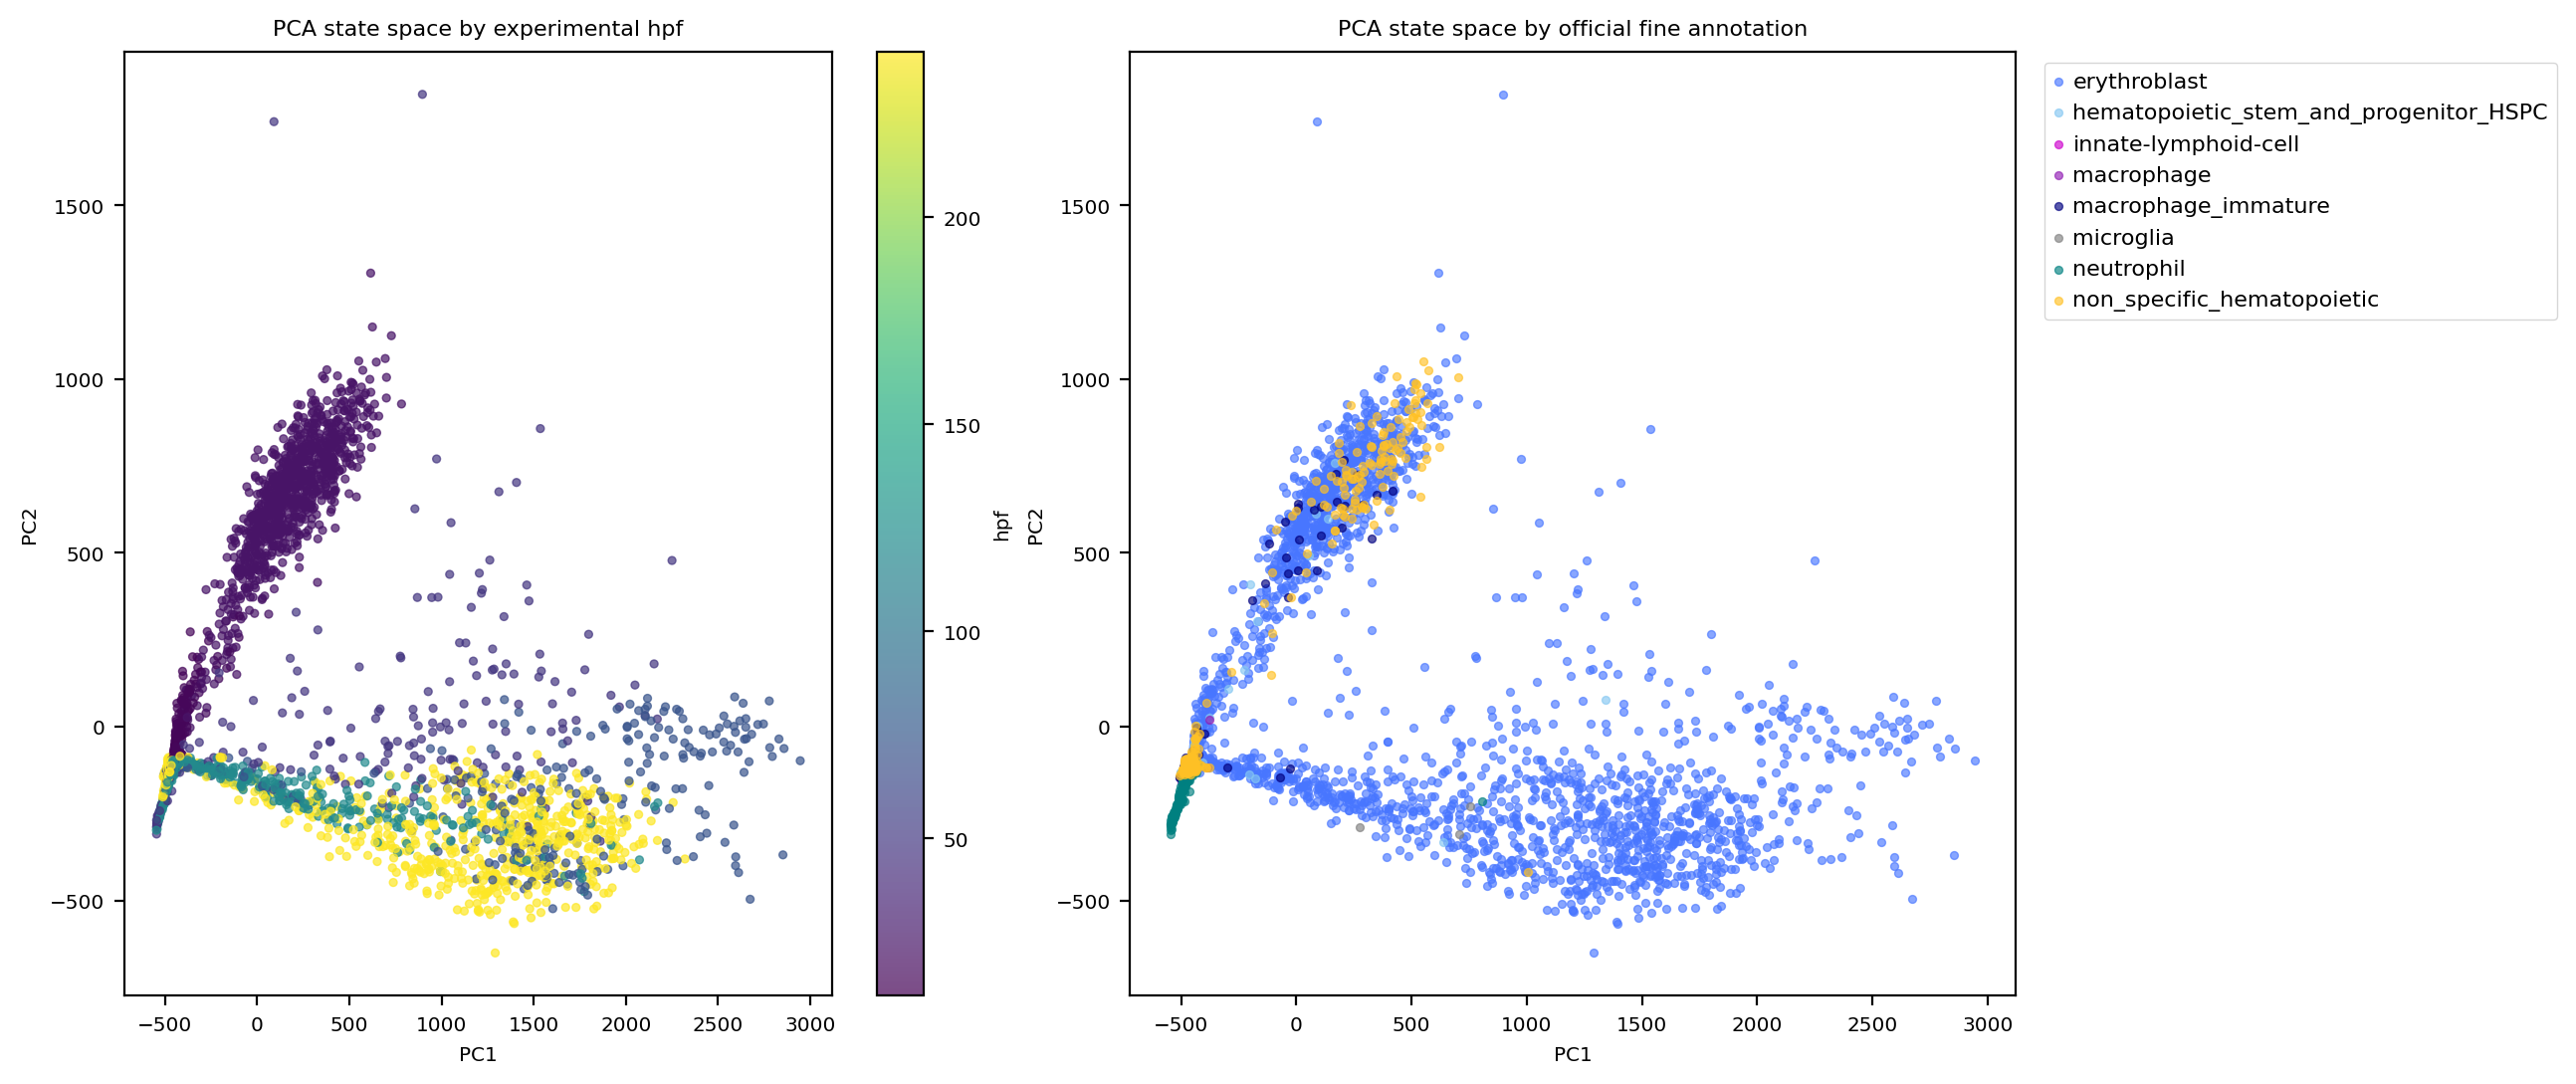

In [12]:
pcs = adata.obsm["X_pca"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

p = axes[0].scatter(
    pcs[:, 0], pcs[:, 1], c=adata.obs["hpf"], cmap="viridis",
    s=8, alpha=0.7, rasterized=True,
)
axes[0].set(title="PCA state space by experimental hpf", xlabel="PC1", ylabel="PC2")
fig.colorbar(p, ax=axes[0], label="hpf")

for official_label in adata.obs["model_cell_type"].cat.categories:
    mask = adata.obs["model_cell_type"].astype(str).eq(str(official_label)).to_numpy()
    axes[1].scatter(
        pcs[mask, 0], pcs[mask, 1], s=8, alpha=0.65,
        label=str(official_label), rasterized=True,
    )
axes[1].set(
    title="PCA state space by official fine annotation", xlabel="PC1", ylabel="PC2"
)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_fine_type_pca_state_space.pdf")
plt.show()


## 8. Audit graph continuity across real time

This diagnostic prevents overclaiming a continuous developmental trajectory
when the neighbor graph contains mostly within-stage edges.

In [13]:
C = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
C_coo = C.tocoo()
hpf = adata.obs["hpf"].to_numpy(float)
edge_audit = pd.DataFrame({
    "source_hpf": hpf[C_coo.row],
    "target_hpf": hpf[C_coo.col],
})
edge_table = pd.crosstab(
    edge_audit["source_hpf"],
    edge_audit["target_hpf"],
    normalize="index",
)
display(edge_table.round(3))

same_hpf_fraction = np.mean(
    edge_audit["source_hpf"].to_numpy() == edge_audit["target_hpf"].to_numpy()
)
print(f"Same-hpf kNN edges: {same_hpf_fraction:.1%}")
if same_hpf_fraction > 0.90:
    warnings.warn(
        "More than 90% of kNN edges remain within the same hpf. Interpret "
        "velocity as local state dynamics; do not claim a single continuous "
        "trajectory spanning all sampled stages."
    )
    

target_hpf,12.0,14.0,16.0,19.0,24.0,48.0,72.0,120.0,240.0
source_hpf,,,,,,,,,
12.0,0.457,0.493,0.016,0.000,0.000,0.016,0.000,0.017,0.002
14.0,0.103,0.575,0.230,0.015,0.008,0.018,0.000,0.039,0.012
16.0,0.001,0.092,0.698,0.102,0.066,0.006,0.001,0.029,0.005
19.0,0.000,0.014,0.247,0.280,0.255,0.051,0.021,0.074,0.056
24.0,0.000,0.001,0.011,0.018,0.910,0.032,0.003,0.014,0.011
48.0,0.001,0.003,0.002,0.009,0.081,0.648,0.044,0.153,0.059
72.0,0.000,0.000,0.000,0.003,0.008,0.040,0.542,0.162,0.245
120.0,0.000,0.002,0.004,0.004,0.010,0.045,0.053,0.747,0.135
240.0,0.000,0.001,0.001,0.003,0.009,0.019,0.088,0.149,0.730


Same-hpf kNN edges: 73.8%


## 9. Dynamo moments and stochastic velocity

`recipe_monocle` has already created Dynamo-compatible normalized layers and
preprocessing flags. This section uses the current 30-neighbor PCA graph to compute
moments, followed by the stochastic steady-state dynamics model. No flags are manually
set to pretend that preprocessing occurred.

In [14]:
assert {"X_spliced", "X_unspliced"}.issubset(adata.layers.keys()), (
    "recipe_monocle did not create normalized X_spliced/X_unspliced layers."
)
A = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
row_sums = np.asarray(A.sum(axis=1)).ravel()
assert np.all(row_sums > 0), "Neighbor graph contains isolated cells."
moments_conn = sp.diags(1.0 / row_sums) @ A

dynamics_genes = adata.var_names[adata.var["pass_basic_filter"].astype(bool)].tolist()
assert len(dynamics_genes) > 0
dyn.tl.moments(
    adata,
    genes=dynamics_genes,
    conn=moments_conn,
    normalize=False,
    use_gaussian_kernel=False,
    layers=["X_spliced", "X_unspliced"],
    n_neighbors=N_NEIGHBORS,
)
assert "M_s" in adata.layers and "M_u" in adata.layers

|-----> calculating first/second moments...


|-----> [moments calculation] completed [0.9725s]



╭─ SUMMARY: moments ─────────────────────────────────────────────────╮
│  Duration: 0.9759s                                                 │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 5426x5426)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 5426x2986)                       │
│           │ ✚ M_ss (sparse matrix, 5426x2986)                      │
│           │ ✚ M_u (sparse matrix, 5426x2986)                       │
│           │ ✚ M_us (sparse matrix, 5426x2986)                      │
│           │ ✚ M_uu (sparse matrix, 5426x2986)                      │
│                                                                    │
╰────

In [15]:
dyn.tl.dynamics(
    adata,
    filter_gene_mode="final",
    use_smoothed=True,
    assumption_mRNA="ss",
    model="stochastic",
    est_method="gmm",
    log_unnormalized=False,
    re_smooth=False,
    del_2nd_moments=False,
    cores=1
)
assert "velocity_S" in adata.layers
print("Dynamo dynamics complete.")

estimating gamma:   0%|          | 0/951 [00:00<?, ?it/s]

estimating gamma:   1%|          | 6/951 [00:00<00:16, 56.49it/s]

estimating gamma:   1%|▏         | 12/951 [00:00<00:18, 50.24it/s]

estimating gamma:   2%|▏         | 18/951 [00:00<00:20, 45.02it/s]

estimating gamma:   2%|▏         | 23/951 [00:00<00:20, 46.21it/s]

...

estimating gamma:  99%|█████████▊| 937/951 [00:29<00:00, 38.40it/s]

estimating gamma:  99%|█████████▉| 942/951 [00:29<00:00, 39.28it/s]

estimating gamma: 100%|█████████▉| 947/951 [00:29<00:00, 39.97it/s]

estimating gamma: 100%|██████████| 951/951 [00:30<00:00, 31.65it/s]


╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 32.1001s                                                │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● LAYERS │ ✚ velocity_S (sparse matrix, 5426x2986)                │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Dynam

## 10. Velocity-gene quality control

The thresholds match the successful pilot:
`gamma > 0`, `gamma_r2 >= 0.01`, finite velocity in at least 95% of cells,
and spliced/unspliced detection in at least 25 cells. The number of passing
genes is data-dependent and is not hard-coded to the pilot's 272 genes.

In [16]:
vel_names = list(adata.uns["vel_params_names"])
vel_params = pd.DataFrame(
    adata.varm["vel_params"],
    index=adata.var_names,
    columns=vel_names,
)

V = adata.layers["velocity_S"]
V_dense = V.toarray() if sp.issparse(V) else np.asarray(V)

def detection_count(matrix):
    return np.asarray((matrix > 0).sum(axis=0)).ravel()

qc = pd.DataFrame(index=adata.var_names)
qc["gamma"] = pd.to_numeric(vel_params["gamma"], errors="coerce")
qc["gamma_r2"] = pd.to_numeric(vel_params["gamma_r2"], errors="coerce")
qc["velocity_finite_fraction"] = np.isfinite(V_dense).mean(axis=0)
qc["spliced_detected_cells"] = detection_count(adata.layers["spliced"])
qc["unspliced_detected_cells"] = detection_count(adata.layers["unspliced"])

valid_velocity_gene = (
    qc["gamma"].gt(0)
    & qc["gamma_r2"].ge(0.01)
    & qc["velocity_finite_fraction"].ge(0.95)
    & qc["spliced_detected_cells"].ge(25)
    & qc["unspliced_detected_cells"].ge(25)
)
adata.var["velocity_qc_pass"] = valid_velocity_gene.to_numpy()
transition_genes = adata.var_names[valid_velocity_gene].tolist()
qc.to_csv(RESULTS_DIR / "velocity_gene_qc.csv")

print("Velocity-QC genes:", len(transition_genes))
assert len(transition_genes) >= 50, (
    "Too few velocity-QC genes. Inspect dynamics and subtype composition "
    "before GraphVelo."
)

Velocity-QC genes: 522


In [17]:
# qc -> 522 

## 
11. GraphVelo in expression and PCA state spaces

If the installed GraphVelo source still uses SciPy sparse `.A`, replace those
package-internal occurrences with `.toarray()` once. Do not monkey-patch the
scientific data object.

In [18]:
# Compatibility bridge:
# convert the existing Scanpy neighbor graph into the neighbor-index
# format required by this installed GraphVelo version.

distances = adata.obsp["distances"].tocsr()
n_cells = adata.n_obs
n_neighbors = N_NEIGHBORS

neighbor_indices = np.empty(
    (n_cells, n_neighbors),
    dtype=np.int64,
)

for cell_index in range(n_cells):
    start = distances.indptr[cell_index]
    end = distances.indptr[cell_index + 1]

    row_neighbors = distances.indices[start:end]
    row_distances = distances.data[start:end]

    # Arrange existing neighbors by increasing PCA distance.
    order = np.argsort(row_distances)
    row_neighbors = row_neighbors[order]

    # Dynamo/GraphVelo-style index arrays normally include the cell itself.
    row_neighbors = row_neighbors[
        row_neighbors != cell_index
    ]

    selected = np.concatenate(
        [
            np.array([cell_index], dtype=np.int64),
            row_neighbors[: n_neighbors - 1],
        ]
    )

    # Padding is only needed in the unlikely case that a cell has fewer
    # graph neighbors than requested.
    if len(selected) < n_neighbors:
        selected = np.pad(
            selected,
            (0, n_neighbors - len(selected)),
            mode="edge",
        )

    neighbor_indices[cell_index] = selected

# Preserve the existing Scanpy graph and add only the format GraphVelo needs.
if "neighbors" not in adata.uns:
    adata.uns["neighbors"] = {}

adata.uns["neighbors"]["indices"] = neighbor_indices

print(
    "GraphVelo neighbor indices:",
    adata.uns["neighbors"]["indices"].shape,
)

assert adata.uns["neighbors"]["indices"].shape == (
    adata.n_obs,
    N_NEIGHBORS,
)

assert np.all(
    adata.uns["neighbors"]["indices"] >= 0
)

assert np.all(
    adata.uns["neighbors"]["indices"] < adata.n_obs
)

GraphVelo neighbor indices: (5426, 30)


In [19]:
from graphvelo.graph_velocity import GraphVelo

gene_mask = adata.var_names.isin(transition_genes)
X_train = adata.layers["M_s"][:, gene_mask]
V_train = adata.layers["velocity_S"][:, gene_mask]
assert np.isfinite(
    X_train.data if sp.issparse(X_train) else np.asarray(X_train)
).all()
assert np.isfinite(
    V_train.data if sp.issparse(V_train) else np.asarray(V_train)
).all()

gv = GraphVelo(
    adata,
    gene_subset=transition_genes,
    xkey="M_s",
    vkey="velocity_S",
)
gv.train()

adata.layers["velocity_gv"] = gv.project_velocity(adata.layers["M_s"])
adata.obsm["gv_pca"] = gv.project_velocity(adata.obsm["X_pca"])
gv.write_to_adata(adata, key="graphvelo")

assert adata.obsm["gv_pca"].shape == adata.obsm["X_pca"].shape
assert np.isfinite(adata.obsm["gv_pca"]).all()
print("GraphVelo training and PCA projection complete.")

Learning Phi in tangent space projection.:   0%|          | 0/5426 [00:00<?, ?it/s]

Learning Phi in tangent space projection.:   1%|          | 64/5426 [00:04<05:47, 15.41it/s]

Learning Phi in tangent space projection.:   1%|          | 64/5426 [00:14<05:47, 15.41it/s]

Learning Phi in tangent space projection.:   2%|▏         | 128/5426 [03:37<2:55:49,  1.99s/it]

Learning Phi in tangent space projection.:   2%|▏         | 129/5426 [03:38<2:53:47,  1.97s/it]

...

projecting velocity vector to low dimensional embedding:  61%|██████    | 3299/5426 [00:00<00:00, 6796.95it/s]

projecting velocity vector to low dimensional embedding:  74%|███████▍  | 4002/5426 [00:00<00:00, 6873.39it/s]

projecting velocity vector to low dimensional embedding:  87%|████████▋ | 4710/5426 [00:00<00:00, 6937.90it/s]

projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:00<00:00, 6788.72it/s]

GraphVelo training and PCA projection complete.


In [20]:
V_input = np.asarray(gv.V)
V_fit = np.asarray(gv.project_velocity(gv.X))
input_norm = np.linalg.norm(V_input, axis=1)
fit_norm = np.linalg.norm(V_fit, axis=1)
denom = input_norm * fit_norm
fit_cosine = np.divide(
    np.sum(V_input * V_fit, axis=1),
    denom,
    out=np.full(len(denom), np.nan),
    where=denom > 0,
)
print(pd.Series(fit_cosine).describe())
if np.nanmedian(fit_cosine) <= 0:
    raise RuntimeError(
        "Median GraphVelo fit cosine is non-positive. Stop before interpreting "
        "directions or weights."
    )

projecting velocity vector to low dimensional embedding:   0%|          | 0/5426 [00:00<?, ?it/s]

projecting velocity vector to low dimensional embedding:  11%|█▏        | 617/5426 [00:00<00:00, 6169.20it/s]

projecting velocity vector to low dimensional embedding:  25%|██▌       | 1359/5426 [00:00<00:00, 6900.87it/s]

projecting velocity vector to low dimensional embedding:  39%|███▊      | 2102/5426 [00:00<00:00, 7141.67it/s]

projecting velocity vector to low dimensional embedding:  53%|█████▎    | 2891/5426 [00:00<00:00, 7434.70it/s]

projecting velocity vector to low dimensional embedding:  67%|██████▋   | 3643/5426 [00:00<00:00, 7463.99it/s]

projecting velocity vector to low dimensional embedding:  81%|████████  | 4394/5426 [00:00<00:00, 7478.46it/s]

projecting velocity vector to low dimensional embedding:  95%|█████████▍| 5142/5426 [00:00<00:00, 7474.29it/s]

projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:00<00:00, 7335.05it/s]

count    5426.000000
mean        0.508466
std         0.152492
min         0.062338
25%         0.397115
50%         0.506277
75%         0.613106
max         0.918590
dtype: float64


## 12. Validate/import moscot

Use the `vae_gpu` kernel. Package installation is never performed inside this notebook. The exact verified versions are recorded in `environment.yml`; the same imports can be checked before a run with:

```bash
conda run -n vae_gpu python validate_vae_gpu_environment.py
```

Orthology is not queried during notebook execution. The analysis uses the frozen provenance-rich ZFIN mapping table built by `build_expanded_growth_marker_panel.py`.


In [21]:
import importlib
import anndata as ad

# Compatibility patch for the mudata version installed in ~/.local.
ad_core = importlib.import_module("anndata._core")
ad_file_backing = importlib.import_module("anndata._core.file_backing")

setattr(ad_core, "file_backing", ad_file_backing)
setattr(ad, "_core", ad_core)

# Confirm the attribute required by mudata is now available.
assert hasattr(ad, "_core")
assert hasattr(ad._core, "file_backing")
assert hasattr(ad._core.file_backing, "AnnDataFileManager")

import mudata
import moscot
from moscot.problems.time import TemporalProblem

print("anndata:", ad.__version__, ad.__file__)
print("mudata:", mudata.__version__, mudata.__file__)
print("moscot:", moscot.__version__, moscot.__file__)
print("TemporalProblem imported successfully.")

anndata: 0.10.9 /net/dali/home/mscbio/jis322/.local/lib/python3.11/site-packages/anndata/__init__.py
mudata: 0.3.8 /net/dali/home/mscbio/jis322/.local/lib/python3.11/site-packages/mudata/__init__.py
moscot: 0.5.1 /net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/moscot/__init__.py
TemporalProblem imported successfully.


## 13. Model configuration — no Top-K truncation

In [22]:
# OT parameters: initial values only; report sensitivity before final conclusions.
MOSCOT_EPSILON = 1e-2
MOSCOT_TAU_A = 0.9
MOSCOT_TAU_B = 0.9
N_PCS_MOSCOT = 30

# Growth time is expressed in days so 24 hpf = 1 day. This prevents the
# exponent from being inflated by using hour-sized time differences.
GROWTH_SCALING = 5.0

# Frozen consensus panel: external cell-cycle/pathway evidence + ZFIN orthology.
ORTHOLOG_MAPPING_MODE = "reviewed_external_consensus_csv"
REVIEWED_ORTHOLOG_CSV = (
    PROJECT_DIR.parent / "reviewed_zebrafish_to_human_growth_orthologs_expanded.csv"
)
MARKER_SOURCE_MANIFEST = (
    PROJECT_DIR.parent / "growth_marker_reference" / "source_manifest.csv"
)

# Fail early if the expanded panel is accidentally replaced by the old small panel.
MIN_PROLIFERATION_GENES = 75
MIN_APOPTOSIS_GENES = 25

# Retain rare pro-death transcripts while rejecting genes that are completely absent
# from the modeled cells. Detection is measured from raw counts, before normalization.
MIN_MARKER_DETECTION_FRACTION = 0.005

# Keep the full moscot coupling; do not introduce a custom velocity-weighted OT layer.
EXPORT_CELL_LEVEL_EDGE_TABLES = False

# Optional native-moscot sensitivity refits; disabled for the main run.
RUN_MOSCOT_SENSITIVITY = False
SENSITIVITY_SCALINGS = [2.5, 5.0, 10.0]
SENSITIVITY_EPSILONS = [5e-3, 1e-2, 5e-2]
N_FISH_BOOTSTRAPS = 1000
N_VELOCITY_PERMUTATIONS = 500

print("Custom OT/velocity reweighting: OFF; native moscot transport only.")

Custom OT/velocity reweighting: OFF; native moscot transport only.


## 14. Shared cells, state space and real experimental time

moscot and GraphVelo must use the same cells and PCA coordinates. We keep hpf for
reporting but use `time_days = hpf / 24` for the growth formula

\[
g_i^{prior}=\exp\left(\frac{(p_i-a_i)(t_1-t_0)}{scaling}\right).
\]

In [23]:
required_obsm = {"X_pca", "gv_pca"}
required_obs = {"hpf", "official_fine_cell_type", "fish_id"}
assert required_obsm.issubset(adata.obsm.keys())
assert required_obs.issubset(adata.obs.columns)

adata.obs["hpf"] = pd.to_numeric(adata.obs["hpf"], errors="raise").astype(float)
adata.obs["time_days"] = adata.obs["hpf"] / 24.0
adata.obs["official_fine_cell_type"] = pd.Categorical(
    adata.obs["official_fine_cell_type"]
)
adata.obs["fish_id"] = adata.obs["fish_id"].astype(str)

X_ot = np.asarray(adata.obsm["X_pca"], dtype=float)[:, :N_PCS_MOSCOT]
V_ot = np.asarray(adata.obsm["gv_pca"], dtype=float)[:, :N_PCS_MOSCOT]
assert X_ot.shape == V_ot.shape
assert np.isfinite(X_ot).all() and np.isfinite(V_ot).all()

adata.obsm["X_moscot"] = X_ot.copy()
hpf = adata.obs["hpf"].to_numpy(float)
time_days = adata.obs["time_days"].to_numpy(float)
cell_types = adata.obs["official_fine_cell_type"].astype(str).to_numpy()
fish_ids = adata.obs["fish_id"].astype(str).to_numpy()

hpf_values = np.sort(np.unique(hpf))
hpf_pairs = list(zip(hpf_values[:-1], hpf_values[1:]))
day_values = hpf_values / 24.0
day_pairs = list(zip(day_values[:-1], day_values[1:]))
pair_lookup = dict(zip(day_pairs, hpf_pairs))

display(
    adata.obs.groupby("hpf", observed=True)
    .agg(n_cells=("fish_id", "size"), n_fish=("fish_id", "nunique"))
)
print("Sequential hpf pairs:", hpf_pairs)

,n_cells,n_fish
hpf,,
12.0,19,4
14.0,77,4
16.0,186,4
19.0,79,4
24.0,1177,4
48.0,466,4
72.0,528,4
120.0,1456,4
240.0,1438,4


Sequential hpf pairs: [(np.float64(12.0), np.float64(14.0)), (np.float64(14.0), np.float64(16.0)), (np.float64(16.0), np.float64(19.0)), (np.float64(19.0), np.float64(24.0)), (np.float64(24.0), np.float64(48.0)), (np.float64(48.0), np.float64(72.0)), (np.float64(72.0), np.float64(120.0)), (np.float64(120.0), np.float64(240.0))]


## 15. Build a dedicated log-normalized object for growth scoring

The OT coordinates remain `X_moscot`; only gene scoring uses log-normalized total
counts. This prevents the preprocessing state of Dynamo from silently changing the
proliferation/apoptosis scores.

In [24]:
# The velocity H5AD contains only 3,000 selected genes, so it cannot support
# proliferation scoring. Read raw counts for the same cells from the official
# 27,435-gene hematopoietic/endothelial object instead.
full_expression = ad.read_h5ad(FULL_EXPRESSION_H5AD, backed="r")
assert full_expression.obs_names.is_unique
assert full_expression.var_names.is_unique
full_pos = full_expression.obs_names.get_indexer(adata.obs_names)
assert (full_pos >= 0).all(), (
    "Some modeled velocity cells are absent from the full-expression object."
)
full_counts = sp.csr_matrix(full_expression.layers["counts"][full_pos, :])
full_var = full_expression.var.copy()
full_expression.file.close()
del full_expression

adata_ot = ad.AnnData(
    X=full_counts.copy(), obs=adata.obs.copy(), var=full_var
)
adata_ot.layers["counts"] = full_counts.copy()
assert adata_ot.obs_names.equals(adata.obs_names)

# Copy the shared state space and time metadata from the velocity object.
adata_ot.obsm["X_pca"] = adata.obsm["X_pca"].copy()
adata_ot.obsm["X_moscot"] = adata.obsm["X_moscot"].copy()

# Apply log-normalization only to the dedicated growth-scoring object.
adata_ot.X = adata_ot.layers["counts"].copy()
sc.pp.normalize_total(adata_ot, target_sum=1e4)
sc.pp.log1p(adata_ot)
assert np.isfinite(
    adata_ot.X.data if sp.issparse(adata_ot.X) else np.asarray(adata_ot.X)
).all()
print("Growth-scoring object:", adata_ot)
print(f"Available genes for marker scoring: {adata_ot.n_vars} (full expression matrix)")

Growth-scoring object: AnnData object with n_obs × n_vars = 5426 × 27435
    obs: 'clusters', 'seurat_clusters', 'timepoint', 'fish', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'official_fine_cell_type', 'hpf', 'fish_id', 'model_cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'ntr', 'time_days'
    var: 'mean', 'n_cells', 'nc', 'n_cells_by_counts', 'mt', 'genome', 'mean_counts', 'variance', 'feature_types', 'gene_ids', 'total_counts', 'pct_dropout_by_counts', 'log1p_mean_counts', 'log1p_total_counts'
    uns: 'log1p'
    obsm: 'X_pca', 'X_moscot'
    layers: 'counts'
Available genes for marker scoring: 27435 (full expression matrix)


## 16. Reviewed mapping: zebrafish markers → human orthologs

The scoring genes below are zebrafish symbols present in the expression matrix.
Their human orthologs are recorded separately in a frozen, reviewed CSV using
ZFIN's manually curated orthology data; teleost one-to-many mappings remain explicit.

Orthology supports cross-species interpretation but does not by itself prove conserved
expression or function, so final claims also require concordant human marker evidence.

Evidence used for this panel:
- ZFIN manually curated human–zebrafish orthology (`human_orthos.txt`; current download: https://zfin.org/downloads).
- Tirosh et al., Science 2016, human single-cell G1/S and G2/M programs (PMID: 27124452).
- Velten et al., Nature Cell Biology 2017, human HSPC cell-cycle programs (GEO: GSE75478).
- Macaulay et al., Cell Reports 2016, zebrafish hematopoietic differentiation and coordinated proliferation-program suppression (PMCID: PMC4742565).
- Xia et al., PNAS 2021, zebrafish CHT HSPC atlas compared with human fetal liver (PMID: 33785593; GEO: GSE120503/GSE120578/GSE120509/GSE146404/GSE120581).

The 16,940 entries in `all_genes.txt` are the eligible zebrafish feature universe.
Only the reviewed cell-cycle subset below is scored as proliferation.

In [25]:
# all_genes.txt is the complete zebrafish candidate universe, not a proliferation list.
ALL_ZEBRAFISH_GENES_FILE = PROJECT_DIR.parent / "all_genes.txt"
with ALL_ZEBRAFISH_GENES_FILE.open() as handle:
    ZEBRAFISH_CANDIDATE_GENE_UNIVERSE = [line.strip() for line in handle if line.strip()]
assert len(ZEBRAFISH_CANDIDATE_GENE_UNIVERSE) == len(
    set(ZEBRAFISH_CANDIDATE_GENE_UNIVERSE)
), "all_genes.txt contains duplicate feature names; resolve these before scoring."
candidate_lookup = {gene.casefold(): gene for gene in ZEBRAFISH_CANDIDATE_GENE_UNIVERSE}

if ORTHOLOG_MAPPING_MODE == "reviewed_external_consensus_csv":
    if not REVIEWED_ORTHOLOG_CSV.exists():
        raise FileNotFoundError(f"Expanded ortholog table not found: {REVIEWED_ORTHOLOG_CSV}")
    if not MARKER_SOURCE_MANIFEST.exists():
        raise FileNotFoundError(f"Marker source manifest not found: {MARKER_SOURCE_MANIFEST}")

    ortholog_map = pd.read_csv(REVIEWED_ORTHOLOG_CSV)
    marker_source_manifest = pd.read_csv(MARKER_SOURCE_MANIFEST)
    required = {
        "zebrafish_gene", "human_gene", "marker_class", "marker_subclass",
        "mapping_direction", "mapping_database", "evidence_status",
        "pathway_sources", "selection_rule", "source_urls",
    }
    assert required.issubset(ortholog_map.columns), (
        f"Expanded mapping is missing columns: {sorted(required - set(ortholog_map.columns))}"
    )
    assert ortholog_map[list(required)].notna().all().all()
    assert ortholog_map["marker_class"].isin(["proliferation", "apoptosis"]).all()
    assert ortholog_map["mapping_direction"].eq("zebrafish_to_human").all()
    assert ortholog_map["evidence_status"].eq("reviewed_external_consensus").all()
    assert not ortholog_map.duplicated(
        ["zebrafish_gene", "human_gene", "marker_class"]
    ).any()
else:
    raise ValueError(f"Unknown ORTHOLOG_MAPPING_MODE: {ORTHOLOG_MAPPING_MODE}")

# These are zebrafish symbols only. Human symbols stay in ortholog_map for provenance
# and later cross-species validation; they are never used to index adata_ot.
ZEBRAFISH_PROLIFERATION_MARKERS = sorted(
    ortholog_map.loc[
        ortholog_map["marker_class"].eq("proliferation"), "zebrafish_gene"
    ].astype(str).unique()
)
ZEBRAFISH_APOPTOSIS_MARKERS = sorted(
    ortholog_map.loc[
        ortholog_map["marker_class"].eq("apoptosis"), "zebrafish_gene"
    ].astype(str).unique()
)

missing_from_candidate_universe = sorted(
    gene for gene in ZEBRAFISH_PROLIFERATION_MARKERS + ZEBRAFISH_APOPTOSIS_MARKERS
    if gene.casefold() not in candidate_lookup
)
assert not missing_from_candidate_universe, (
    f"Mapped zebrafish markers absent from all_genes.txt: {missing_from_candidate_universe}"
)

ortholog_map.to_csv(
    RESULTS_DIR / "zebrafish_to_human_growth_ortholog_mapping_full.csv", index=False
)
marker_source_manifest.to_csv(RESULTS_DIR / "growth_marker_source_manifest.csv", index=False)

panel_inventory = (
    ortholog_map.groupby(["marker_class", "marker_subclass"], observed=True)
    .agg(
        zebrafish_genes=("zebrafish_gene", "nunique"),
        human_genes=("human_gene", "nunique"),
    )
    .reset_index()
)
print("Expanded evidence-mapped panel:")
display(panel_inventory)
display(marker_source_manifest)
display(ortholog_map.head())

Expanded evidence-mapped panel:


,marker_class,marker_subclass,zebrafish_genes,human_genes
0,apoptosis,execution_apoptosis,9,7
1,apoptosis,extrinsic_apoptosis,10,8
2,apoptosis,intrinsic_apoptosis,14,12
3,apoptosis,stress_pro_apoptotic,13,11
4,proliferation,G2M_phase,48,44
5,proliferation,S_phase,47,47


,source,use,url,secondary_url_or_local_file,version_or_retrieval
0,Seurat cc.genes.updated.2019,S/G2M phase markers,https://satijalab.org/seurat/reference/cc.gene...,https://doi.org/10.1126/science.aad0501,2019 list
1,KEGG hsa04110,Cell cycle pathway membership,https://www.kegg.jp/pathway/hsa04110,https://rest.kegg.jp/link/hsa/hsa04110,retrieved 2026-09-08
2,KEGG hsa04210,Apoptosis pathway membership,https://www.kegg.jp/pathway/hsa04210,https://rest.kegg.jp/link/hsa/hsa04210,retrieved 2026-09-08
3,Reactome R-HSA-69278/R-HSA-69306,Mitotic cell cycle and DNA replication,https://reactome.org/content/detail/R-HSA-69278,https://reactome.org/content/detail/R-HSA-69306,release downloaded 2026-09-08
4,Reactome R-HSA-109581/R-HSA-109606,Apoptosis and intrinsic apoptosis,https://reactome.org/content/detail/R-HSA-109581,https://reactome.org/content/detail/R-HSA-109606,release downloaded 2026-09-08
5,ZFIN human orthology,Reviewed human-zebrafish orthology,https://zfin.org/downloads/human_orthos.txt,/net/dali/home/mscbio/jis322/dynamo/human_orth...,local snapshot


,zebrafish_gene,human_gene,source_gene,marker_class,marker_subclass,mapping_direction,mapping_database,evidence_status,pathway_sources,n_external_sources,selection_rule,zfin_ids,zfin_evidence_codes,zfin_publications,source_urls
0,acin1a,ACIN1,ACIN1,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,Reactome_Apoptosis_or_Intrinsic_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030616-583,AA;CL,ZDB-PUB-030905-1;ZDB-PUB-050823-6,https://reactome.org/content/detail/R-HSA-1095...
1,acin1b,ACIN1,ACIN1,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,Reactome_Apoptosis_or_Intrinsic_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030826-12,AA;CL,ZDB-PUB-050823-6,https://reactome.org/content/detail/R-HSA-1095...
2,casp2,CASP2,CASP2,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030825-3,AA;CL,ZDB-PUB-030905-1,https://www.kegg.jp/pathway/hsa04210;https://z...
3,casp3a,CASP3,CASP3,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-011210-1,AA;CL;OT;PT,ZDB-PUB-011109-5;ZDB-PUB-030905-1;ZDB-PUB-1609...,https://reactome.org/content/detail/R-HSA-1095...
4,casp3b,CASP3,CASP3,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-070607-1,AA;CL;OT;PT,ZDB-PUB-030905-1;ZDB-PUB-160901-6;ZDB-PUB-2206...,https://reactome.org/content/detail/R-HSA-1095...


## 17. Resolve database output against the actual AnnData genes

g:Profiler column names can differ across client versions, so the resolver detects
the source and target name fields explicitly. It uses case-insensitive matching only
to locate the literal `var_names`; it does not invent gene symbols.

In [26]:
print("First var_names:", adata.var_names[:20].tolist())
print("adata.var columns:", adata.var.columns.tolist())

for col in ["gene_name", "gene_symbol", "symbol", "features", "feature_name"]:
    if col in adata.var.columns:
        print(f"\n{col}:")
        print(adata.var[col].head(20).tolist())

First var_names: ['cplx2l', 'acy3.2', 'pdia2', 'atp1a1a.5', 'atp1a1a.2', 'gja8b', 'anos1a', 'slit2', 'capn9', 'msx1b', 'dlx2b', 'glra3', 'cnn1a', 'ednraa', 'fgb', 'dla', 'adra1d', 'fstl1a', 'mylz3', 'hpgd']
adata.var columns: ['n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_m', 'log_cv', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'velocity_qc_pass']


In [27]:
print(f"\northolog_map columns: {ortholog_map.columns.tolist()}")
print("\northolog_map.head():")
display(ortholog_map.head(10))

print("\n\nReviewed zebrafish genes found in the full scoring object:")
diagnostic_var_lookup = {
    str(gene).casefold(): str(gene) for gene in adata_ot.var_names
}
reviewed_zf_genes = ortholog_map["zebrafish_gene"].dropna().astype(str).unique()
matches = []
for zf_gene in reviewed_zf_genes:
    match = diagnostic_var_lookup.get(zf_gene.casefold())
    if match:
        matches.append((zf_gene, match))

print(f"Found {len(matches)} matches out of {len(reviewed_zf_genes)} reviewed zebrafish genes:")
for orig, matched in sorted(matches):
    print(f"  '{orig}' -> '{matched}'")


ortholog_map columns: ['zebrafish_gene', 'human_gene', 'source_gene', 'marker_class', 'marker_subclass', 'mapping_direction', 'mapping_database', 'evidence_status', 'pathway_sources', 'n_external_sources', 'selection_rule', 'zfin_ids', 'zfin_evidence_codes', 'zfin_publications', 'source_urls']

ortholog_map.head():


,zebrafish_gene,human_gene,source_gene,marker_class,marker_subclass,mapping_direction,mapping_database,evidence_status,pathway_sources,n_external_sources,selection_rule,zfin_ids,zfin_evidence_codes,zfin_publications,source_urls
0,acin1a,ACIN1,ACIN1,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,Reactome_Apoptosis_or_Intrinsic_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030616-583,AA;CL,ZDB-PUB-030905-1;ZDB-PUB-050823-6,https://reactome.org/content/detail/R-HSA-1095...
1,acin1b,ACIN1,ACIN1,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,Reactome_Apoptosis_or_Intrinsic_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030826-12,AA;CL,ZDB-PUB-050823-6,https://reactome.org/content/detail/R-HSA-1095...
2,casp2,CASP2,CASP2,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030825-3,AA;CL,ZDB-PUB-030905-1,https://www.kegg.jp/pathway/hsa04210;https://z...
3,casp3a,CASP3,CASP3,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-011210-1,AA;CL;OT;PT,ZDB-PUB-011109-5;ZDB-PUB-030905-1;ZDB-PUB-1609...,https://reactome.org/content/detail/R-HSA-1095...
4,casp3b,CASP3,CASP3,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-070607-1,AA;CL;OT;PT,ZDB-PUB-030905-1;ZDB-PUB-160901-6;ZDB-PUB-2206...,https://reactome.org/content/detail/R-HSA-1095...
5,casp7,CASP7,CASP7,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-050522-506,AA;CL,ZDB-PUB-030905-1;ZDB-PUB-140513-246;ZDB-PUB-18...,https://reactome.org/content/detail/R-HSA-1095...
6,dffa,DFFA,DFFA,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-040718-376,AA;CL,ZDB-PUB-030905-1,https://reactome.org/content/detail/R-HSA-1095...
7,dffb,DFFB,DFFB,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-030826-4,AA;CL;NT,ZDB-PUB-030905-1;ZDB-PUB-190929-11,https://reactome.org/content/detail/R-HSA-1095...
8,rock1,ROCK1,ROCK1,apoptosis,execution_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,Reactome_Apoptosis_or_Intrinsic_Apoptosis,1,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-100712-2,AA;PT,ZDB-PUB-030905-1;ZDB-PUB-121210-10;ZDB-PUB-180...,https://reactome.org/content/detail/R-HSA-1095...
9,casp8,CASP8,CASP8,apoptosis,extrinsic_apoptosis,zebrafish_to_human,ZFIN human orthology download,reviewed_external_consensus,KEGG_hsa04210_Apoptosis;Reactome_Apoptosis_or_...,2,directionally_curated_pro_death+KEGG_or_Reacto...,ZDB-GENE-000713-1,AA;CL,ZDB-PUB-070504-18;ZDB-PUB-130904-10,https://reactome.org/content/detail/R-HSA-1095...




Reviewed zebrafish genes found in the full scoring object:
Found 141 matches out of 141 reviewed zebrafish genes:
  'OMA1' -> 'oma1'
  'acin1a' -> 'acin1a'
  'acin1b' -> 'acin1b'
  'aifm1' -> 'aifm1'
  'anln' -> 'anln'
  'anp32e' -> 'anp32e'
  'apaf1' -> 'apaf1'
  'atad2' -> 'atad2'
  'aurka' -> 'aurka'
  'aurkb' -> 'aurkb'
  'badb' -> 'badb'
  'baxa' -> 'baxa'
  'baxb' -> 'baxb'
  'bbc3' -> 'bbc3'
  'bcl2l11' -> 'bcl2l11'
  'bida' -> 'bida'
  'birc5a' -> 'birc5a'
  'blm' -> 'blm'
  'bnip3la' -> 'bnip3la'
  'bnip3lb' -> 'bnip3lb'
  'bub1' -> 'bub1'
  'bub3' -> 'bub3'
  'casp2' -> 'casp2'
  'casp3a' -> 'casp3a'
  'casp3b' -> 'casp3b'
  'casp7' -> 'casp7'
  'casp8' -> 'casp8'
  'casp8ap2' -> 'casp8ap2'
  'casp9' -> 'casp9'
  'ccnb1' -> 'ccnb1'
  'ccnb2' -> 'ccnb2'
  'ccne1' -> 'ccne1'
  'cdc20' -> 'cdc20'
  'cdc45' -> 'cdc45'
  'cdc6' -> 'cdc6'
  'cdca7a' -> 'cdca7a'
  'cdk1' -> 'cdk1'
  'cenpf' -> 'cenpf'
  'cenpk' -> 'cenpk'
  'chaf1b' -> 'chaf1b'
  'ckap2l' -> 'ckap2l'
  'ckap5' -> 

In [28]:
# Match mapped zebrafish genes against the full growth-scoring object.
var_lookup = {}
for gene in adata_ot.var_names.astype(str):
    var_lookup.setdefault(gene.casefold(), gene)

ortholog_audit = ortholog_map.copy()
ortholog_audit["source_gene"] = ortholog_audit["human_gene"].astype(str)
ortholog_audit["zebrafish_gene_database"] = ortholog_audit["zebrafish_gene"].astype(str)
ortholog_audit["adata_gene"] = (
    ortholog_audit["zebrafish_gene_database"].str.casefold().map(var_lookup)
)
ortholog_audit["present_in_adata"] = ortholog_audit["adata_gene"].notna()

expected_by_class = {
    "proliferation": {gene.casefold() for gene in ZEBRAFISH_PROLIFERATION_MARKERS},
    "apoptosis": {gene.casefold() for gene in ZEBRAFISH_APOPTOSIS_MARKERS},
}
for marker_class, expected in expected_by_class.items():
    mapped = set(
        ortholog_audit.loc[
            ortholog_audit["marker_class"].eq(marker_class),
            "zebrafish_gene_database",
        ].str.casefold()
    )
    missing = sorted(expected - mapped)
    assert not missing, f"{marker_class} genes absent from expanded mapping: {missing}"

# Quantify raw-count detection in the exact cells used for transport. The score uses
# normalized expression later, but panel inclusion is audited against raw counts.
audit_genes = sorted(ortholog_audit.loc[ortholog_audit["present_in_adata"], "adata_gene"].unique())
audit_counts = adata_ot[:, audit_genes].layers["counts"]
detection_fraction = np.asarray((audit_counts > 0).mean(axis=0)).ravel()
detection_lookup = dict(zip(audit_genes, detection_fraction))
ortholog_audit["raw_count_detection_fraction"] = (
    ortholog_audit["adata_gene"].map(detection_lookup).fillna(0.0)
)
ortholog_audit["passes_detection_filter"] = (
    ortholog_audit["present_in_adata"]
    & ortholog_audit["raw_count_detection_fraction"].ge(MIN_MARKER_DETECTION_FRACTION)
)

ortholog_audit.to_csv(
    RESULTS_DIR / "growth_ortholog_mapping_adata_audit.csv", index=False
)
display(
    ortholog_audit.groupby("marker_class", observed=True)
    .agg(
        mapping_rows=("zebrafish_gene", "size"),
        present_in_adata=("present_in_adata", "sum"),
        pass_detection=("passes_detection_filter", "sum"),
        median_detection_fraction=("raw_count_detection_fraction", "median"),
    )
)

proliferation_genes_zf = sorted(
    ortholog_audit.loc[
        ortholog_audit["marker_class"].eq("proliferation")
        & ortholog_audit["passes_detection_filter"],
        "adata_gene",
    ].dropna().unique()
)
apoptosis_genes_zf = sorted(
    ortholog_audit.loc[
        ortholog_audit["marker_class"].eq("apoptosis")
        & ortholog_audit["passes_detection_filter"],
        "adata_gene",
    ].dropna().unique()
)

active_human_counts = (
    ortholog_audit.loc[ortholog_audit["passes_detection_filter"]]
    .groupby("marker_class", observed=True)["human_gene"]
    .nunique()
    .to_dict()
)
marker_panel_summary = pd.DataFrame(
    {
        "marker_class": ["proliferation", "apoptosis"],
        "active_zebrafish_genes": [len(proliferation_genes_zf), len(apoptosis_genes_zf)],
        "active_unique_human_orthologs": [
            active_human_counts.get("proliferation", 0),
            active_human_counts.get("apoptosis", 0),
        ],
        "minimum_detection_fraction": MIN_MARKER_DETECTION_FRACTION,
    }
)
marker_panel_summary.to_csv(RESULTS_DIR / "growth_marker_panel_summary.csv", index=False)
display(marker_panel_summary)

print("Active zebrafish proliferation genes:", proliferation_genes_zf)
print("Active zebrafish apoptosis genes:", apoptosis_genes_zf)

assert len(proliferation_genes_zf) >= MIN_PROLIFERATION_GENES, (
    f"Only {len(proliferation_genes_zf)} proliferation genes pass the mapping and "
    f"detection filters; expected at least {MIN_PROLIFERATION_GENES}."
)
assert len(apoptosis_genes_zf) >= MIN_APOPTOSIS_GENES, (
    f"Only {len(apoptosis_genes_zf)} pro-death genes pass the mapping and detection "
    f"filters; expected at least {MIN_APOPTOSIS_GENES}."
)

,mapping_rows,present_in_adata,pass_detection,median_detection_fraction
marker_class,,,,
apoptosis,46,46,46,0.105787
proliferation,95,95,95,0.260229


,marker_class,active_zebrafish_genes,active_unique_human_orthologs,minimum_detection_fraction
0,proliferation,95,91,0.005
1,apoptosis,46,38,0.005


Active zebrafish proliferation genes: ['CKS2', 'anln', 'anp32e', 'atad2', 'aurka', 'aurkb', 'birc5a', 'blm', 'bub1', 'bub3', 'casp8ap2', 'ccnb1', 'ccnb2', 'ccne1', 'cdc20', 'cdc45', 'cdc6', 'cdca7a', 'cdk1', 'cenpf', 'cenpk', 'chaf1b', 'ckap2l', 'ckap5', 'cks1b', 'ctcf', 'dlgap5', 'dscc1', 'dtl', 'e2f8', 'ect2', 'exo1', 'fen1', 'g2e3', 'gas2l3', 'gins1', 'gins2', 'gins3', 'gmnn', 'gtse1', 'hells', 'hmgb2a', 'hmgb2b', 'hmmr', 'kif11', 'kif20ba', 'kif20bb', 'kif23', 'kif2c', 'lbr', 'mad2l1', 'mcm10', 'mcm2', 'mcm3', 'mcm4', 'mcm5', 'mcm6', 'mki67', 'mrpl36', 'msh2', 'nasp', 'ncapd2', 'ndc80', 'nek2', 'orc1', 'pcna', 'plk1', 'pola1', 'pola2', 'pold3', 'polr1b', 'prim1', 'rad51', 'rad51ap1', 'rangap1a', 'rangap1b', 'rfc2', 'rfc3', 'rrm1', 'rrm2', 'smc4', 'tacc3', 'tipin', 'tmpoa', 'tmpob', 'top2a', 'tpx2', 'ttk', 'tyms', 'ube2c', 'ubr7', 'uhrf1', 'unga', 'usp1', 'wdr76']
Active zebrafish apoptosis genes: ['acin1a', 'acin1b', 'aifm1', 'apaf1', 'badb', 'baxa', 'baxb', 'bbc3', 'bcl2l11', 'bid

## 18. Fit M0: uniform-marginal moscot baseline

In [29]:
# Native moscot baseline; no custom transport solver is used.
tp_m0 = TemporalProblem(adata_ot)
tp_m0 = tp_m0.prepare(
    time_key="time_days",
    joint_attr="X_moscot",
    policy="sequential",
    cost="sq_euclidean",
    a=False,
    b=False,
)
tp_m0 = tp_m0.solve(
    epsilon=MOSCOT_EPSILON,
    tau_a=MOSCOT_TAU_A,
    tau_b=MOSCOT_TAU_B,
)
print("M0 solutions:", list(tp_m0.solutions))

def audit_temporal_problem(problem, model_name):
    expected = set(day_pairs)
    solved = {(float(a), float(b)) for a, b in problem.solutions}
    assert expected.issubset(solved), f"{model_name} missing pairs: {expected - solved}"
    rows = []
    for d0, d1 in day_pairs:
        solution = problem.solutions[(d0, d1)]
        rows.append({
            "model": model_name,
            "source_day": d0,
            "target_day": d1,
            "converged": getattr(solution, "converged", np.nan),
            "cost": getattr(solution, "cost", np.nan),
        })
    table = pd.DataFrame(rows)
    known = table["converged"].dropna()
    if len(known):
        assert known.astype(bool).all(), f"{model_name} did not converge for every pair"
    return table

convergence_m0 = audit_temporal_problem(tp_m0, "M0")
display(convergence_m0)

INFO     Solving `8` problems                                                                                      


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1177, 466)].                                   


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(19, 77)].                                      


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(186, 79)].                                     


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(466, 528)].                                    


...

INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(79, 1177)].                                    


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(77, 186)].                                     


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(528, 1456)].                                   


M0 solutions: [(1.0, 2.0), (0.5, 0.5833333333333334), (0.6666666666666666, 0.7916666666666666), (2.0, 3.0), (5.0, 10.0), (0.7916666666666666, 1.0), (0.5833333333333334, 0.6666666666666666), (3.0, 5.0)]


,model,source_day,target_day,converged,cost
0,M0,0.500000,0.583333,True,0.122789
1,M0,0.583333,0.666667,True,0.116868
2,M0,0.666667,0.791667,True,0.101007
3,M0,0.791667,1.000000,True,0.111582
4,M0,1.000000,2.000000,True,0.119083
5,M0,2.000000,3.000000,True,0.067842
6,M0,3.000000,5.000000,True,0.061877
7,M0,5.000000,10.000000,True,0.062629


## 19. Fit M1: expanded zebrafish growth-informed moscot

`score_genes_for_marginals` calculates proliferation and apoptosis scores from the
**zebrafish** genes that pass orthology, candidate-universe, and raw-count detection
checks. The proliferation panel combines S-phase and G2/M markers. The apoptosis panel
contains only directionally pro-death intrinsic, extrinsic, execution, and stress genes;
anti-apoptotic pathway members are excluded.

During `prepare`, moscot converts these two expression scores into time-interval-specific
marginals. The gene scores are biological inputs; moscot supplies the estimation
framework. Larger panels improve coverage, but do not by themselves prove that the
growth prior is correct—M0/M1 sensitivity and independent biological validation remain
required.

In [30]:
tp_m1 = TemporalProblem(adata_ot)
tp_m1 = tp_m1.score_genes_for_marginals(
    gene_set_proliferation=proliferation_genes_zf,
    gene_set_apoptosis=apoptosis_genes_zf,
    proliferation_key="zf_proliferation_score",
    apoptosis_key="zf_apoptosis_score",
    random_state=SEED,
)

tp_m1 = tp_m1.prepare(
    time_key="time_days",
    joint_attr="X_moscot",
    policy="sequential",
    cost="sq_euclidean",
    marginal_kwargs={"scaling": GROWTH_SCALING},
)
adata_ot.obs["moscot_prior_growth_rate"] = tp_m1.prior_growth_rates

tp_m1 = tp_m1.solve(
    epsilon=MOSCOT_EPSILON,
    tau_a=MOSCOT_TAU_A,
    tau_b=MOSCOT_TAU_B,
)
convergence_m1 = audit_temporal_problem(tp_m1, "M1")
moscot_convergence = pd.concat([convergence_m0, convergence_m1], ignore_index=True)
moscot_convergence.to_csv(RESULTS_DIR / "moscot_convergence_M0_M1.csv", index=False)
display(moscot_convergence)
adata_ot.obs["moscot_posterior_growth_rate"] = tp_m1.posterior_growth_rates

growth_summary = adata_ot.obs[
    [
        "hpf", "official_fine_cell_type", "zf_proliferation_score",
        "zf_apoptosis_score", "moscot_prior_growth_rate",
        "moscot_posterior_growth_rate",
    ]
].copy()
growth_summary.to_csv(RESULTS_DIR / "cell_level_growth_scores.csv")
display(growth_summary.describe(include="all"))

INFO     Solving `8` problems                                                                                      


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1177, 466)].                                   


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(19, 77)].                                      


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(186, 79)].                                     


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(466, 528)].                                    


...

INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(77, 186)].                                     


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(528, 1456)].                                   


,model,source_day,target_day,converged,cost
0,M0,0.500000,0.583333,True,0.122789
1,M0,0.583333,0.666667,True,0.116868
2,M0,0.666667,0.791667,True,0.101007
3,M0,0.791667,1.000000,True,0.111582
4,M0,1.000000,2.000000,True,0.119083
5,M0,2.000000,3.000000,True,0.067842
6,M0,3.000000,5.000000,True,0.061877
7,M0,5.000000,10.000000,True,0.062629
8,M1,0.500000,0.583333,True,0.122787
9,M1,0.583333,0.666667,True,0.116873


/net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/moscot/problems/time/_mixins.py:452: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df_1, df_2], verify_integrity=True)


,hpf,official_fine_cell_type,zf_proliferation_score,zf_apoptosis_score,moscot_prior_growth_rate,moscot_posterior_growth_rate
count,5426.000000,5426,5426.000000,5426.000000,3988.000000,3.988000e+03
unique,NaN,8,NaN,NaN,NaN,NaN
top,NaN,erythroblast,NaN,NaN,NaN,NaN
freq,NaN,2358,NaN,NaN,NaN,NaN
mean,113.205861,NaN,0.053464,-0.015498,1.023528,6.843010e+00
std,84.614240,NaN,0.165007,0.044887,0.038775,2.331942e+02
min,12.000000,NaN,-0.215215,-0.159333,0.936974,2.069528e-25
25%,24.000000,NaN,-0.084535,-0.047453,0.988130,1.759356e-01
50%,120.000000,NaN,-0.017381,-0.020861,1.024617,1.046709e+00
75%,240.000000,NaN,0.197857,0.012072,1.054960,1.165407e+00


## 20. Read native moscot couplings without modifying transport

These helpers only expose moscot's solved matrices for auditing. They do not
define a second OT objective or alter any coupling weights.

In [31]:
def moscot_solution_to_csr(solution):
    matrix = solution.transport_matrix
    if sp.issparse(matrix):
        out = matrix.tocsr().astype(float)
    else:
        out = sp.csr_matrix(np.asarray(matrix, dtype=float))
    out.eliminate_zeros()
    if out.nnz:
        assert np.isfinite(out.data).all()
        assert (out.data >= 0).all()
    return out

def conditionalize_rows(matrix):
    matrix = matrix.tocsr()
    row_mass = np.asarray(matrix.sum(axis=1)).ravel()
    inv = np.divide(
        1.0, row_mass,
        out=np.zeros_like(row_mass, dtype=float),
        where=row_mass > 0,
    )
    return (sp.diags(inv) @ matrix).tocsr(), row_mass

def effective_target_count(matrix_cond):
    matrix_cond = matrix_cond.tocsr()
    values = matrix_cond.data
    rows = np.repeat(
        np.arange(matrix_cond.shape[0]), np.diff(matrix_cond.indptr)
    )
    entropy = np.bincount(
        rows,
        weights=-values * np.log(np.maximum(values, np.finfo(float).tiny)),
        minlength=matrix_cond.shape[0],
    )
    out = np.exp(entropy)
    out[np.asarray(matrix_cond.sum(axis=1)).ravel() <= 0] = np.nan
    return out

## 21. Audit native moscot mass and conditional fate

M1 is the primary model. M0 is retained only as a no-growth baseline. No Top-K
pruning or velocity-based reweighting is applied.

In [32]:
pair_results = {}

for day_pair, hpf_pair in pair_lookup.items():
    d0, d1 = day_pair
    t0, t1 = hpf_pair
    source_global = np.flatnonzero(time_days == d0)
    target_global = np.flatnonzero(time_days == d1)

    P0_raw = moscot_solution_to_csr(tp_m0.solutions[(d0, d1)])
    P1_raw = moscot_solution_to_csr(tp_m1.solutions[(d0, d1)])
    expected_shape = (len(source_global), len(target_global))
    assert P0_raw.shape == P1_raw.shape == expected_shape

    P0_cond, g0 = conditionalize_rows(P0_raw)
    P1_cond, g1 = conditionalize_rows(P1_raw)

    pair_results[(t0, t1)] = {
        "source_global": source_global,
        "target_global": target_global,
        "M0_raw": P0_raw,
        "M0_cond": P0_cond,
        "M0_growth_mass": g0,
        "M1_raw": P1_raw,
        "M1_cond": P1_cond,
        "M1_growth_mass": g1,
    }

print("Audited native moscot couplings for:", list(pair_results))

Audited native moscot couplings for: [(np.float64(12.0), np.float64(14.0)), (np.float64(14.0), np.float64(16.0)), (np.float64(16.0), np.float64(19.0)), (np.float64(19.0), np.float64(24.0)), (np.float64(24.0), np.float64(48.0)), (np.float64(48.0), np.float64(72.0)), (np.float64(72.0), np.float64(120.0)), (np.float64(120.0), np.float64(240.0))]


## 22. Velocity innovation: independent moscot–GraphVelo concordance

The moscot coupling is not changed. For each source cell, its native M1 conditional
coupling defines a barycentric displacement toward the next time point. We compare
that displacement with GraphVelo using cosine direction, magnitude ratio, conditional
transport dispersion, and effective target count. A within-time velocity permutation
test asks whether agreement exceeds chance. This avoids circular validation.

In [33]:
rng_velocity = np.random.default_rng(SEED)
velocity_cell_frames = []
velocity_pair_rows = []

for (t0, t1), result in pair_results.items():
    source_idx = result["source_global"]
    target_idx = result["target_global"]
    P_cond = result["M1_cond"].tocsr()

    X_source = X_ot[source_idx]
    X_target = X_ot[target_idx]
    V_graphvelo = V_ot[source_idx]
    delta_days = (t1 - t0) / 24.0

    # Conditional moscot barycenter and its implied state-space velocity.
    target_barycenter = np.asarray(P_cond @ X_target)
    V_moscot = (target_barycenter - X_source) / delta_days

    gv_norm = np.linalg.norm(V_graphvelo, axis=1)
    mt_norm = np.linalg.norm(V_moscot, axis=1)
    denom = gv_norm * mt_norm
    valid = (denom > 0) & (result["M1_growth_mass"] > 0)
    cosine = np.full(len(source_idx), np.nan)
    cosine[valid] = np.clip(
        np.sum(V_graphvelo[valid] * V_moscot[valid], axis=1) / denom[valid],
        -1.0, 1.0,
    )
    magnitude_ratio = np.divide(
        gv_norm, mt_norm, out=np.full_like(gv_norm, np.nan), where=mt_norm > 0
    )

    # Conditional target uncertainty around each moscot barycenter.
    second_moment = np.asarray(P_cond @ np.sum(X_target ** 2, axis=1)).ravel()
    transport_variance = np.maximum(
        second_moment - np.sum(target_barycenter ** 2, axis=1), 0.0
    )
    transport_dispersion = np.sqrt(transport_variance)
    n_effective_targets = effective_target_count(P_cond)

    frame = pd.DataFrame({
        "cell_id": adata_ot.obs_names[source_idx].astype(str),
        "source_hpf": t0,
        "target_hpf": t1,
        "source_cell_type": cell_types[source_idx],
        "fish_id": fish_ids[source_idx],
        "proliferation_score": adata_ot.obs["zf_proliferation_score"].to_numpy()[source_idx],
        "apoptosis_score": adata_ot.obs["zf_apoptosis_score"].to_numpy()[source_idx],
        "prior_growth_rate": adata_ot.obs["moscot_prior_growth_rate"].to_numpy()[source_idx],
        "posterior_growth_rate": adata_ot.obs["moscot_posterior_growth_rate"].to_numpy()[source_idx],
        "moscot_graphvelo_cosine": cosine,
        "graphvelo_magnitude": gv_norm,
        "moscot_barycentric_magnitude": mt_norm,
        "graphvelo_to_moscot_magnitude_ratio": magnitude_ratio,
        "transport_dispersion": transport_dispersion,
        "effective_target_count": n_effective_targets,
        "native_moscot_source_mass": result["M1_growth_mass"],
    })
    velocity_cell_frames.append(frame)

    valid_idx = np.flatnonzero(valid)
    assert len(valid_idx) > 0, f"No valid velocity vectors for {t0:g}→{t1:g} hpf"

    # Treat fish—not cells—as the independent unit for the interval-level mean.
    valid_fish = fish_ids[source_idx][valid_idx]
    valid_cosine = cosine[valid_idx]
    fish_mean_values = (
        pd.DataFrame({"fish_id": valid_fish, "cosine": valid_cosine})
        .groupby("fish_id", observed=True)["cosine"]
        .mean()
        .to_numpy()
    )
    observed_fish_mean = float(fish_mean_values.mean())
    bootstrap_fish_mean = rng_velocity.choice(
        fish_mean_values,
        size=(N_FISH_BOOTSTRAPS, len(fish_mean_values)),
        replace=True,
    ).mean(axis=1)

    # Shuffle GraphVelo vectors within each fish and time interval. This preserves
    # fish-specific distributions while breaking cell-specific direction matching.
    fish_local_indices = [
        np.flatnonzero(valid_fish == label) for label in np.unique(valid_fish)
    ]
    null_means = np.empty(N_VELOCITY_PERMUTATIONS, dtype=float)
    for b in range(N_VELOCITY_PERMUTATIONS):
        permuted_velocity = V_graphvelo[valid_idx].copy()
        for local_indices in fish_local_indices:
            permuted_velocity[local_indices] = V_graphvelo[
                valid_idx[rng_velocity.permutation(local_indices)]
            ]
        null_denom = (
            np.linalg.norm(permuted_velocity, axis=1) * mt_norm[valid_idx]
        )
        null_cosine = np.sum(
            permuted_velocity * V_moscot[valid_idx], axis=1
        ) / null_denom
        null_frame = pd.DataFrame({
            "fish_id": valid_fish,
            "cosine": null_cosine,
        })
        null_means[b] = null_frame.groupby(
            "fish_id", observed=True
        )["cosine"].mean().mean()

    p_greater = float(
        (1 + np.sum(null_means >= observed_fish_mean))
        / (N_VELOCITY_PERMUTATIONS + 1)
    )
    p_less = float(
        (1 + np.sum(null_means <= observed_fish_mean))
        / (N_VELOCITY_PERMUTATIONS + 1)
    )
    velocity_pair_rows.append({
        "source_hpf": t0,
        "target_hpf": t1,
        "n_valid_cells": len(valid_idx),
        "n_fish": len(fish_mean_values),
        "cell_weighted_mean_cosine": float(np.mean(valid_cosine)),
        "fish_weighted_mean_cosine": observed_fish_mean,
        "fish_bootstrap_ci_low": float(np.quantile(bootstrap_fish_mean, 0.025)),
        "fish_bootstrap_ci_high": float(np.quantile(bootstrap_fish_mean, 0.975)),
        "within_fish_permuted_mean_cosine": float(null_means.mean()),
        "permutation_p_greater": p_greater,
        "permutation_p_less": p_less,
        "permutation_p_two_sided": min(1.0, 2.0 * min(p_greater, p_less)),
        "median_transport_dispersion": float(np.median(transport_dispersion)),
        "median_effective_targets": float(np.median(n_effective_targets)),
    })

velocity_cell_audit = pd.concat(velocity_cell_frames, ignore_index=True)
velocity_cell_audit["proliferation_quartile"] = pd.qcut(
    velocity_cell_audit["proliferation_score"].rank(method="average"),
    4, labels=["Q1_low", "Q2", "Q3", "Q4_high"],
)
velocity_pair_audit = pd.DataFrame(velocity_pair_rows)
for p_column in [
    "permutation_p_greater", "permutation_p_less", "permutation_p_two_sided",
]:
    velocity_pair_audit[p_column.replace("_p_", "_q_")] = multipletests(
        velocity_pair_audit[p_column], method="fdr_bh"
    )[1]

positive_concordance = (
    velocity_pair_audit["fish_weighted_mean_cosine"].gt(0)
    & velocity_pair_audit["fish_bootstrap_ci_low"].gt(0)
    & velocity_pair_audit["permutation_q_greater"].lt(0.05)
)
negative_discordance = (
    velocity_pair_audit["fish_weighted_mean_cosine"].lt(0)
    & velocity_pair_audit["fish_bootstrap_ci_high"].lt(0)
    & velocity_pair_audit["permutation_q_less"].lt(0.05)
)
velocity_pair_audit["directional_evidence"] = np.select(
    [positive_concordance, negative_discordance],
    ["positive_concordance", "negative_discordance"],
    default="insufficient_or_mixed",
)
velocity_cell_audit.to_csv(RESULTS_DIR / "moscot_graphvelo_cell_audit.csv", index=False)
velocity_pair_audit.to_csv(RESULTS_DIR / "moscot_graphvelo_permutation_test.csv", index=False)
display(velocity_pair_audit)

,source_hpf,target_hpf,n_valid_cells,n_fish,cell_weighted_mean_cosine,fish_weighted_mean_cosine,fish_bootstrap_ci_low,fish_bootstrap_ci_high,within_fish_permuted_mean_cosine,permutation_p_greater,permutation_p_less,permutation_p_two_sided,median_transport_dispersion,median_effective_targets,permutation_q_greater,permutation_q_less,permutation_q_two_sided,directional_evidence
0,12.0,14.0,19,4,0.708989,0.702299,0.599878,0.804721,0.711188,0.534930,0.467066,0.934132,13.119442,6.293761,0.611349,1.000000,0.934132,insufficient_or_mixed
1,14.0,16.0,77,4,0.140609,0.144084,0.000176,0.283319,0.129796,0.325349,0.676647,0.650699,23.185425,10.267557,0.433799,1.000000,0.743656,insufficient_or_mixed
2,16.0,19.0,186,4,0.137227,0.157612,0.077518,0.215405,0.095457,0.001996,1.000000,0.003992,30.078868,3.517600,0.003992,1.000000,0.007984,positive_concordance
3,19.0,24.0,79,4,0.188136,0.260887,-0.054749,0.502462,0.237530,0.177645,0.824351,0.355289,105.181194,101.369531,0.284232,1.000000,0.473719,insufficient_or_mixed
4,24.0,48.0,1177,4,-0.003335,0.010532,-0.031964,0.053028,-0.008508,0.001996,1.000000,0.003992,153.877394,5.450740,0.003992,1.000000,0.007984,insufficient_or_mixed
5,48.0,72.0,466,4,0.248736,0.200617,0.104989,0.264835,0.067721,0.001996,1.000000,0.003992,185.186705,226.912890,0.003992,1.000000,0.007984,positive_concordance
6,72.0,120.0,528,4,-0.003119,-0.010966,-0.135071,0.108747,0.004186,0.920160,0.081836,0.163673,166.193028,423.967196,0.920160,0.654691,0.261876,insufficient_or_mixed
7,120.0,240.0,1456,4,-0.094035,-0.091062,-0.137811,-0.033078,-0.131725,0.001996,1.000000,0.003992,142.933854,387.183276,0.003992,1.000000,0.007984,insufficient_or_mixed


## 23. Aggregate native moscot mass and conditional fate separately

`source_mass_fraction` reports how much of the pair's raw mass originates from a
source type. `conditional_target_fraction` reports where that source type goes after
conditioning. Keeping both prevents growth and fate from being conflated.

In [34]:
def aggregate_by_type(result, matrix_key, t0, t1, model):
    matrix = result[matrix_key].tocoo()
    src_global = result["source_global"][matrix.row]
    tgt_global = result["target_global"][matrix.col]
    frame = pd.DataFrame({
        "source_hpf": t0,
        "target_hpf": t1,
        "source": cell_types[src_global],
        "target": cell_types[tgt_global],
        "mass": matrix.data,
    })
    grouped = (
        frame.groupby(
            ["source_hpf", "target_hpf", "source", "target"],
            observed=True,
        )["mass"].sum().reset_index()
    )
    source_mass = grouped.groupby("source", observed=True)["mass"].transform("sum")
    grouped["conditional_target_fraction"] = grouped["mass"] / source_mass
    grouped["source_mass_fraction"] = source_mass / grouped["mass"].sum()
    grouped["model"] = model
    grouped["matrix_kind"] = "raw"
    return grouped

aggregate_frames = []
for (t0, t1), result in pair_results.items():
    for model in ["M0", "M1"]:
        aggregate_frames.append(
            aggregate_by_type(result, f"{model}_raw", t0, t1, model)
        )

type_transitions = pd.concat(aggregate_frames, ignore_index=True)
type_transitions.to_csv(
    RESULTS_DIR / "moscot_M0_M1_type_transitions.csv",
    index=False,
)
display(type_transitions.head())

,source_hpf,target_hpf,source,target,mass,conditional_target_fraction,source_mass_fraction,model,matrix_kind
0,12.0,14.0,erythroblast,erythroblast,3.998349e-04,2.489227e-03,0.311476,M0,raw
1,12.0,14.0,erythroblast,hematopoietic_stem_and_progenitor_HSPC,1.749211e-10,1.088995e-09,0.311476,M0,raw
2,12.0,14.0,erythroblast,macrophage,8.600022e-03,5.354061e-02,0.311476,M0,raw
3,12.0,14.0,erythroblast,macrophage_immature,1.513543e-01,9.422765e-01,0.311476,M0,raw
4,12.0,14.0,erythroblast,non_specific_hematopoietic,2.720500e-04,1.693684e-03,0.311476,M0,raw


### Time- and cell-type support gates

Transport can be fitted for sparse groups, but sparse estimates must not be presented as equally reliable. A type-level claim is retained only when both time points contain at least 50 cells and both the source and target types contain at least 20 cells from at least three fish at their respective time points.


In [35]:
from transport_support_audit import audit_transport_support

transport_support = audit_transport_support(
    adata_ot,
    type_transitions,
    RESULTS_DIR,
    min_time_cells=50,
    min_type_cells=20,
    min_fish=3,
)
type_transitions = transport_support["annotated_transitions"]
supported_type_transitions = transport_support["supported_transitions"]
display(transport_support["time_support"])
display(transport_support["pair_support"])


,hpf,total_cells,total_fish,passes_time_support
0,12.0,19,4,False
1,14.0,77,4,True
2,16.0,186,4,True
3,19.0,79,4,True
4,24.0,1177,4,True
5,48.0,466,4,True
6,72.0,528,4,True
7,120.0,1456,4,True
8,240.0,1438,4,True


,source_hpf,target_hpf,total_rows,supported_rows,source_time_cells,source_time_fish,target_time_cells,target_time_fish,supported_row_fraction,has_any_supported_type_transition
0,12.0,14.0,40,0,19,4,77,4,0.000000,False
1,14.0,16.0,60,12,77,4,186,4,0.200000,True
2,16.0,19.0,72,6,186,4,79,4,0.083333,True
3,19.0,24.0,84,12,79,4,1177,4,0.142857,True
4,24.0,48.0,98,60,1177,4,466,4,0.612245,True
5,48.0,72.0,98,50,466,4,528,4,0.510204,True
6,72.0,120.0,112,80,528,4,1456,4,0.714286,True
7,120.0,240.0,128,128,1456,4,1438,4,1.000000,True


## 24. Visualize native moscot growth, fate, and velocity agreement

,source_hpf,target_hpf,source,M0,M1,growth_change_M1_minus_M0,source_type_supported,source_time_supported,target_time_supported,supported_for_source_mass_claim
42,120.0,240.0,erythroblast,0.220835,0.239701,0.018867,True,True,True,True
46,120.0,240.0,macrophage_immature,0.056322,0.069560,0.013238,True,True,True,True
35,72.0,120.0,erythroblast,0.220344,0.228306,0.007962,True,True,True,True
31,48.0,72.0,macrophage_immature,0.179145,0.184072,0.004928,True,True,True,True
21,24.0,48.0,erythroblast,0.238507,0.242810,0.004303,True,True,True,True
43,120.0,240.0,hematopoietic_stem_and_progenitor_HSPC,0.147044,0.150730,0.003685,True,True,True,True
25,24.0,48.0,macrophage_immature,0.206861,0.210309,0.003448,True,True,True,True
39,72.0,120.0,macrophage_immature,0.041852,0.044651,0.002800,False,True,True,False
41,72.0,120.0,non_specific_hematopoietic,0.106679,0.109061,0.002381,True,True,True,True
15,19.0,24.0,erythroblast,0.483418,0.484982,0.001564,True,True,True,True


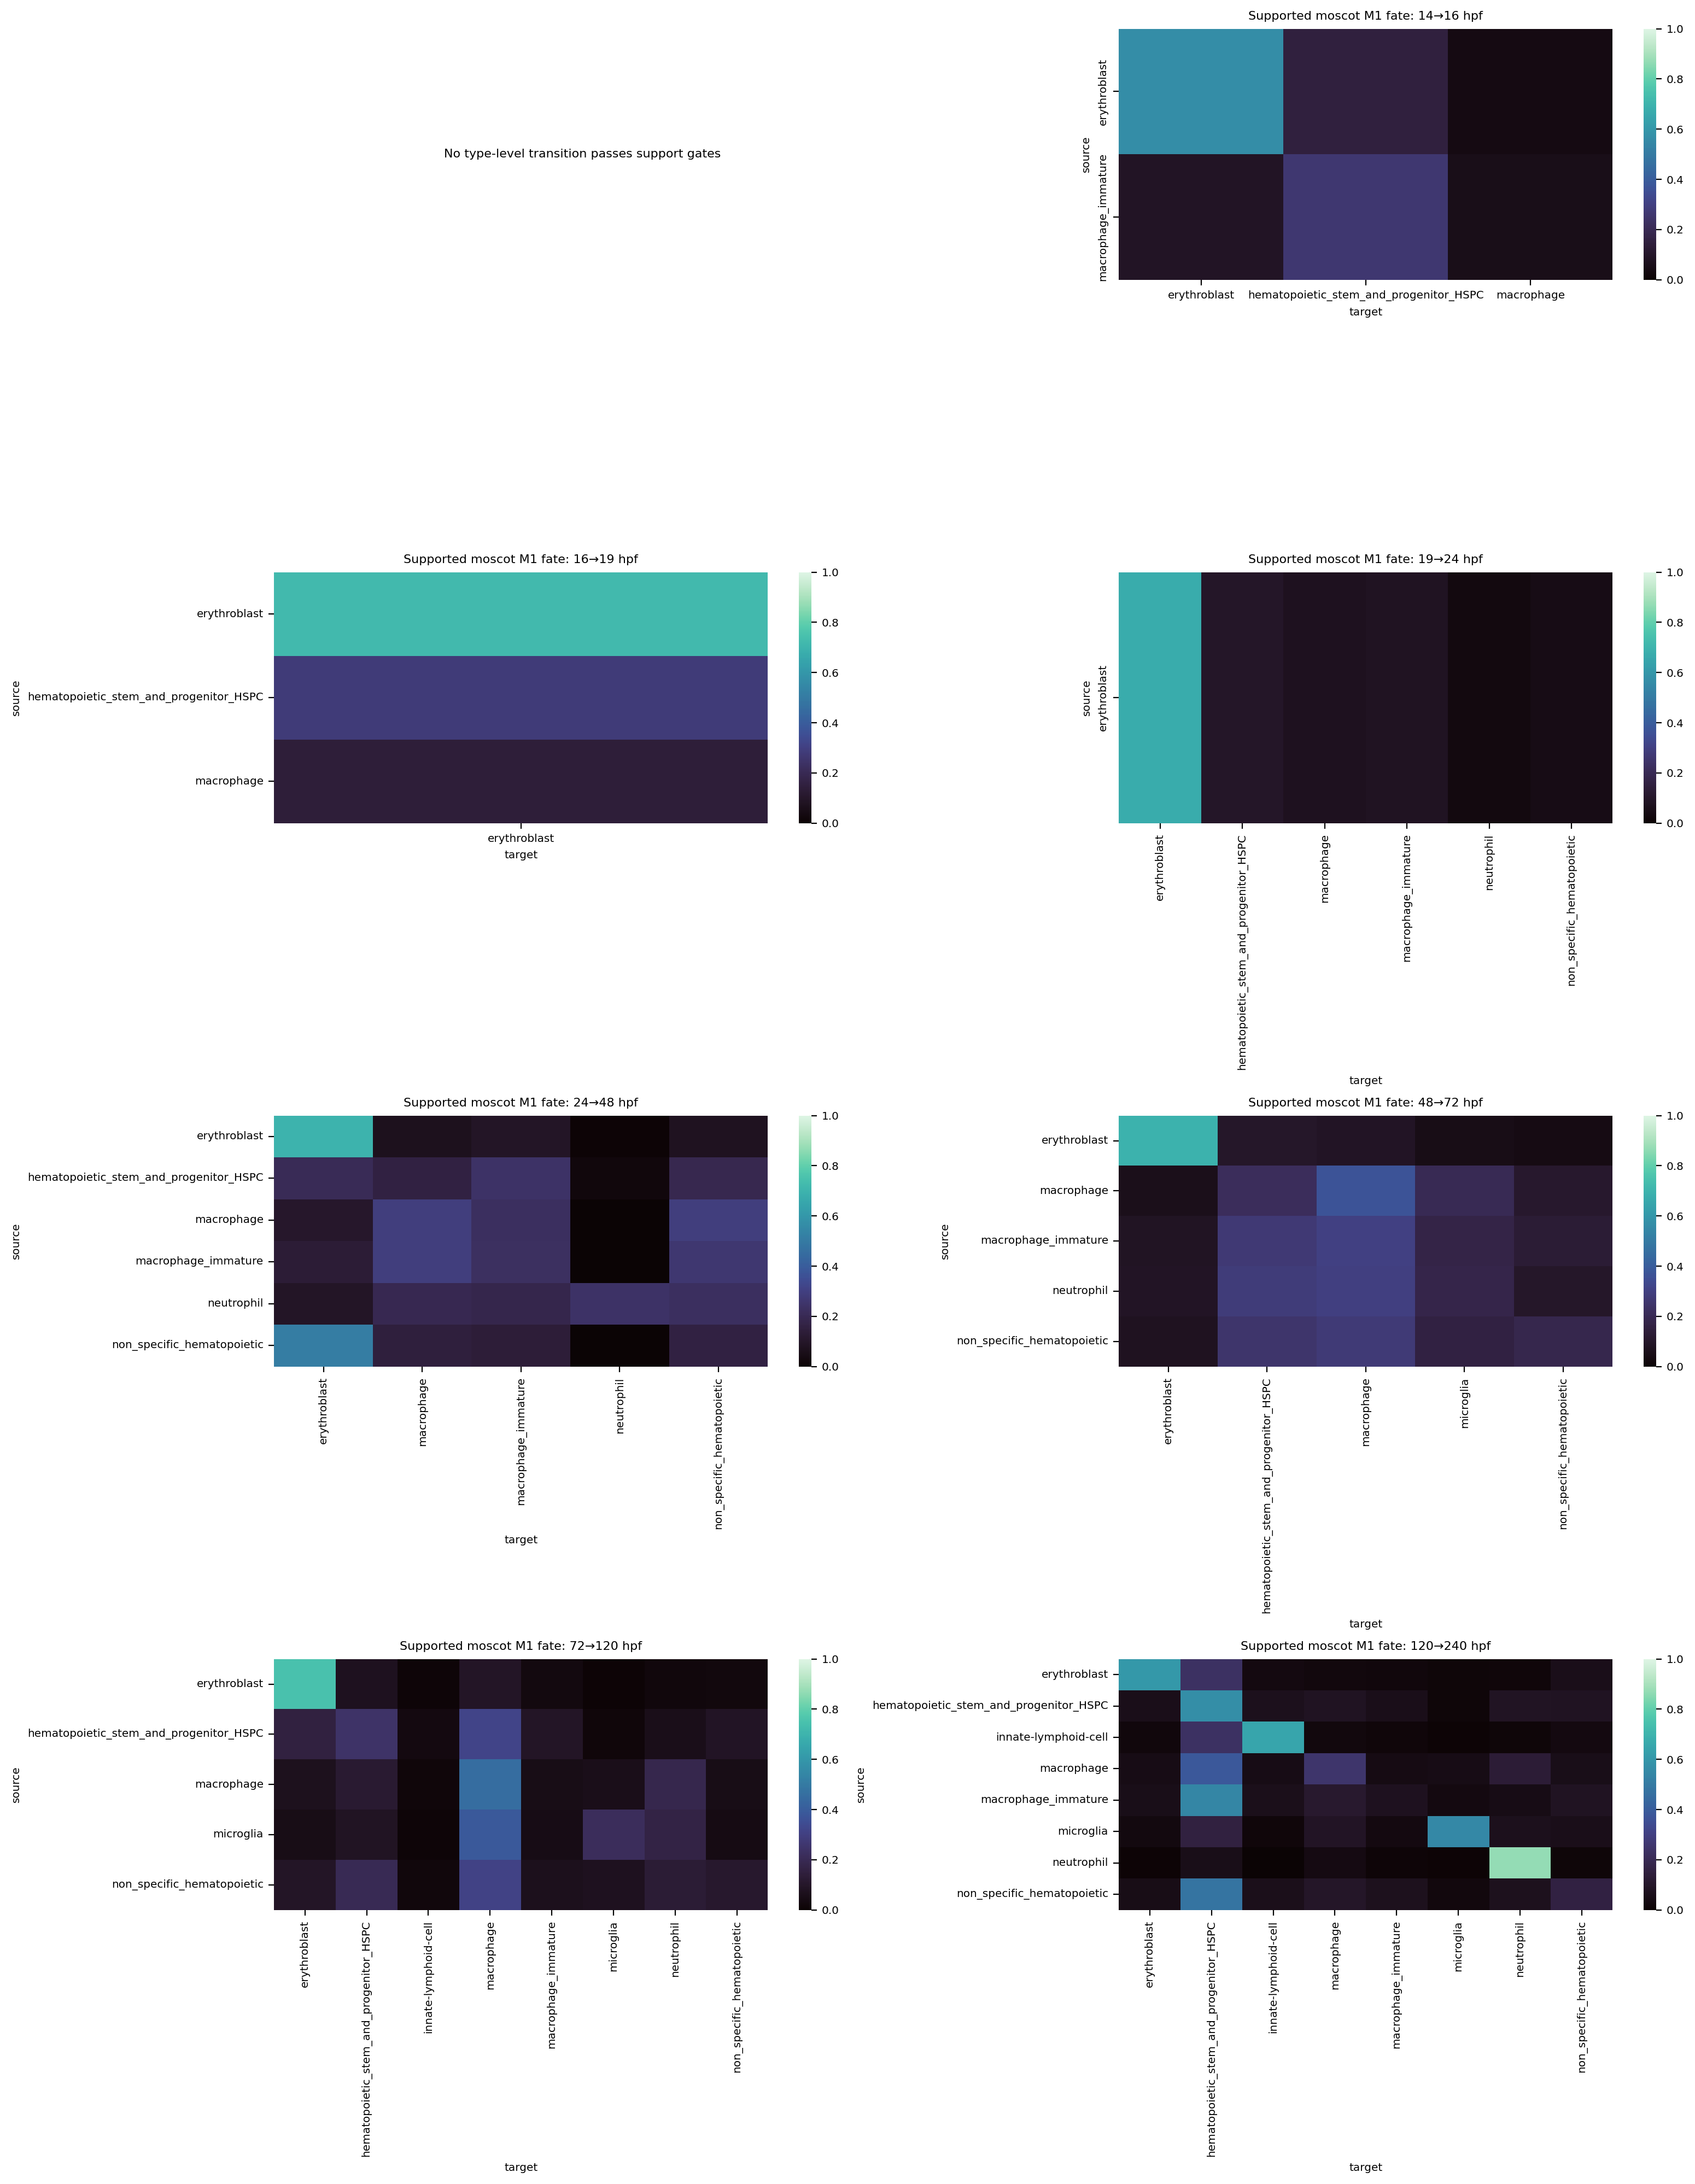

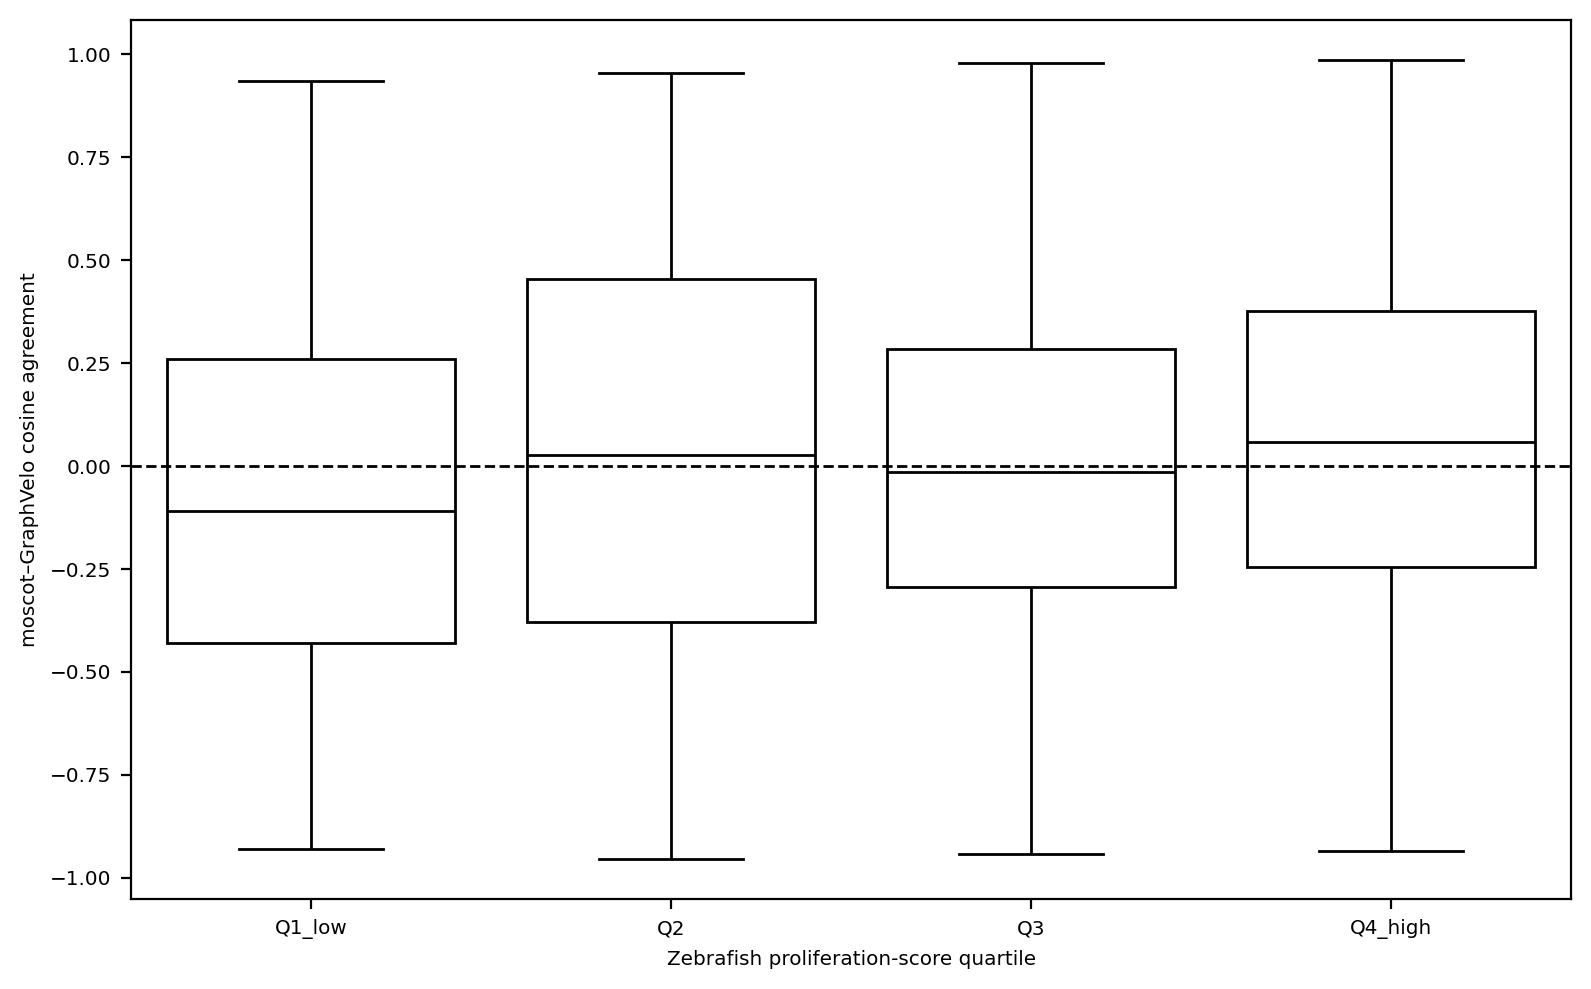

In [36]:
source_mass_table = (
    type_transitions[
        ["source_hpf", "target_hpf", "source", "model", "source_mass_fraction"]
    ]
    .drop_duplicates()
    .pivot_table(
        index=["source_hpf", "target_hpf", "source"],
        columns="model",
        values="source_mass_fraction",
        observed=True,
    )
    .reset_index()
)
if {"M0", "M1"}.issubset(source_mass_table.columns):
    source_mass_table["growth_change_M1_minus_M0"] = (
        source_mass_table["M1"] - source_mass_table["M0"]
    )
source_claim_support = (
    type_transitions[[
        "source_hpf", "target_hpf", "source",
        "source_type_supported", "source_time_supported",
        "target_time_supported",
    ]]
    .drop_duplicates()
)
source_claim_support["supported_for_source_mass_claim"] = (
    source_claim_support[[
        "source_type_supported", "source_time_supported",
        "target_time_supported",
    ]].all(axis=1)
)
source_mass_table = source_mass_table.merge(
    source_claim_support,
    on=["source_hpf", "target_hpf", "source"],
    how="left",
)
source_mass_table.to_csv(
    RESULTS_DIR / "growth_effect_M0_vs_M1_by_cell_type.csv", index=False
)
display(source_mass_table.sort_values(
    "growth_change_M1_minus_M0", ascending=False
).head(30))

m1_only = supported_type_transitions[
    supported_type_transitions["model"].eq("M1")
]
n_pairs = len(hpf_pairs)
ncols = 2
nrows = int(np.ceil(n_pairs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), squeeze=False)
for ax, (t0, t1) in zip(axes.ravel(), hpf_pairs):
    subset = m1_only[
        m1_only["source_hpf"].eq(t0) & m1_only["target_hpf"].eq(t1)
    ]
    if subset.empty:
        ax.text(
            0.5, 0.5, "No type-level transition passes support gates",
            ha="center", va="center", transform=ax.transAxes,
        )
        ax.set_axis_off()
    else:
        table = subset.pivot_table(
            index="source", columns="target",
            values="conditional_target_fraction", fill_value=0.0,
            observed=True,
        )
        sns.heatmap(table, cmap="mako", vmin=0, vmax=1, ax=ax)
        ax.set_title(f"Supported moscot M1 fate: {t0:g}→{t1:g} hpf")
for ax in axes.ravel()[n_pairs:]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "moscot_M1_conditional_fate_heatmaps.pdf")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=velocity_cell_audit, x="proliferation_quartile",
    y="moscot_graphvelo_cosine", color="white",
    fliersize=0, linecolor="black",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Zebrafish proliferation-score quartile")
plt.ylabel("moscot–GraphVelo cosine agreement")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "velocity_agreement_by_proliferation_quartile.pdf")
plt.show()

## 25. Innovation: fish-aware uncertainty for velocity concordance

Cells from the same fish are not independent replicates. We therefore bootstrap
fish IDs—not individual cells—to obtain confidence intervals for mean moscot–
GraphVelo direction agreement within each time pair and source cell type.

In [37]:
rng_bootstrap = np.random.default_rng(SEED + 1)
bootstrap_rows = []
group_cols = ["source_hpf", "target_hpf", "source_cell_type"]

for keys, frame in velocity_cell_audit.groupby(group_cols, observed=True):
    frame = frame.dropna(subset=["moscot_graphvelo_cosine"])
    fish_groups = {
        fish: values["moscot_graphvelo_cosine"].to_numpy(float)
        for fish, values in frame.groupby("fish_id", observed=True)
    }
    fish = np.array(list(fish_groups), dtype=object)
    if len(fish) < 2:
        continue
    boot = np.empty(N_FISH_BOOTSTRAPS, dtype=float)
    for b in range(N_FISH_BOOTSTRAPS):
        sampled = rng_bootstrap.choice(fish, size=len(fish), replace=True)
        boot[b] = np.mean(np.concatenate([fish_groups[f] for f in sampled]))
    bootstrap_rows.append({
        "source_hpf": keys[0],
        "target_hpf": keys[1],
        "source_cell_type": keys[2],
        "n_cells": len(frame),
        "n_fish": len(fish),
        "mean_cosine": frame["moscot_graphvelo_cosine"].mean(),
        "fish_bootstrap_ci_low": np.quantile(boot, 0.025),
        "fish_bootstrap_ci_high": np.quantile(boot, 0.975),
    })

velocity_fish_bootstrap = pd.DataFrame(bootstrap_rows)
velocity_fish_bootstrap.to_csv(
    RESULTS_DIR / "moscot_graphvelo_fish_bootstrap.csv", index=False
)
display(velocity_fish_bootstrap.head(20))

,source_hpf,target_hpf,source_cell_type,n_cells,n_fish,mean_cosine,fish_bootstrap_ci_low,fish_bootstrap_ci_high
0,12.0,14.0,erythroblast,6,2,0.841051,0.839398,0.849315
1,12.0,14.0,macrophage_immature,5,2,0.668290,0.574091,0.731090
2,12.0,14.0,non_specific_hematopoietic,7,3,0.649807,0.320326,0.795091
3,14.0,16.0,erythroblast,34,4,-0.085288,-0.321328,0.044250
4,14.0,16.0,macrophage,2,2,0.315944,0.111985,0.519904
5,14.0,16.0,macrophage_immature,20,4,0.538218,0.446585,0.719200
6,14.0,16.0,non_specific_hematopoietic,18,4,0.060865,-0.200966,0.314428
7,16.0,19.0,erythroblast,105,4,-0.135058,-0.196685,-0.107158
8,16.0,19.0,hematopoietic_stem_and_progenitor_HSPC,29,4,0.635303,0.460355,0.778763
9,16.0,19.0,macrophage,23,4,0.564794,0.438036,0.707182


## 26. Interpretation guardrails

Velocity is used as an external concordance measurement, not as a second set of
weights inside moscot. A positive cosine supports directional agreement; it does not
prove a lineage edge. High transport dispersion or many effective targets indicates
uncertainty even when the mean direction agrees.

In [38]:
velocity_validation_manifest = {
    "transport_model": "native moscot M1 growth-informed coupling",
    "velocity_model": "GraphVelo projected into X_moscot",
    "coupling_modified_by_velocity": False,
    "primary_direction_metric": "per-cell barycentric cosine",
    "uncertainty_metrics": [
        "transport_dispersion", "effective_target_count",
        "within-time velocity permutation", "fish-level bootstrap",
    ],
    "interpretation": (
        "Concordance is complementary evidence, not a causal lineage proof."
    ),
}
display(pd.Series(velocity_validation_manifest, name="value"))

transport_model                          native moscot M1 growth-informed coupling
velocity_model                                   GraphVelo projected into X_moscot
coupling_modified_by_velocity                                                False
primary_direction_metric                               per-cell barycentric cosine
uncertainty_metrics              [transport_dispersion, effective_target_count,...
interpretation                   Concordance is complementary evidence, not a c...
Name: value, dtype: object

## 27. Optional native-moscot sensitivity analysis

If enabled, this section refits native moscot over growth-scaling and
entropic-regularization values and checks
whether posterior growth estimates remain correlated with the primary fit.

In [39]:
if RUN_MOSCOT_SENSITIVITY:
    sensitivity_rows = []
    main_posterior = np.asarray(tp_m1.posterior_growth_rates, dtype=float)
    for scaling in SENSITIVITY_SCALINGS:
        for epsilon in SENSITIVITY_EPSILONS:
            tp_test = TemporalProblem(adata_ot)
            tp_test = tp_test.score_genes_for_marginals(
                gene_set_proliferation=proliferation_genes_zf,
                gene_set_apoptosis=apoptosis_genes_zf,
                proliferation_key="zf_proliferation_score",
                apoptosis_key="zf_apoptosis_score",
                random_state=SEED,
            )
            tp_test = tp_test.prepare(
                time_key="time_days", joint_attr="X_moscot",
                policy="sequential", cost="sq_euclidean",
                marginal_kwargs={"scaling": scaling},
            )
            tp_test = tp_test.solve(
                epsilon=epsilon, tau_a=MOSCOT_TAU_A, tau_b=MOSCOT_TAU_B
            )
            posterior = np.asarray(tp_test.posterior_growth_rates, dtype=float)
            finite = np.isfinite(main_posterior) & np.isfinite(posterior)
            sensitivity_rows.append({
                "growth_scaling": scaling,
                "epsilon": epsilon,
                "posterior_growth_correlation_with_main": (
                    np.corrcoef(main_posterior[finite], posterior[finite])[0, 1]
                    if finite.sum() > 1 else np.nan
                ),
                "median_posterior_growth": np.nanmedian(posterior),
            })
    moscot_sensitivity = pd.DataFrame(sensitivity_rows)
    moscot_sensitivity.to_csv(
        RESULTS_DIR / "native_moscot_parameter_sensitivity.csv", index=False
    )
    display(moscot_sensitivity)
else:
    print("Native moscot sensitivity refits disabled for the main run.")

Native moscot sensitivity refits disabled for the main run.


## 28. Save matrices, checkpoint and manifest

In [40]:
# Rectangular cross-time matrices cannot be stored in AnnData.obsp. Save each
# matrix with explicit source/target IDs in compressed NPZ files.
coupling_dir = RESULTS_DIR / "couplings_no_topk"
coupling_dir.mkdir(parents=True, exist_ok=True)

coupling_index = []
for (t0, t1), result in pair_results.items():
    pair_name = f"{t0:g}_to_{t1:g}_hpf"
    pd.Series(
        adata.obs_names[result["source_global"]], name="cell_id"
    ).to_csv(coupling_dir / f"{pair_name}_source_cells.csv", index=False)
    pd.Series(
        adata.obs_names[result["target_global"]], name="cell_id"
    ).to_csv(coupling_dir / f"{pair_name}_target_cells.csv", index=False)
    for key in ["M0_raw", "M0_cond", "M1_raw", "M1_cond"]:
        path = coupling_dir / f"{pair_name}_{key}.npz"
        sp.save_npz(path, result[key].tocsr())
        coupling_index.append({
            "source_hpf": t0, "target_hpf": t1,
            "matrix": key, "path": str(path),
            "shape": str(result[key].shape), "nnz": result[key].nnz,
        })
pd.DataFrame(coupling_index).to_csv(
    RESULTS_DIR / "coupling_file_index.csv", index=False
)

for column in [
    "zf_proliferation_score", "zf_apoptosis_score",
    "moscot_prior_growth_rate", "moscot_posterior_growth_rate",
]:
    adata.obs[column] = adata_ot.obs[column].to_numpy()

adata.uns["growth_graphvelo_moscot_manifest"] = {
    "models": "M0_uniform baseline; M1_native_moscot_growth primary",
    "time_key_for_ot": "time_days",
    "reporting_time_key": "hpf",
    "state_space": "X_moscot",
    "graphvelo_velocity": "gv_pca first N_PCS_MOSCOT dimensions",
    "ortholog_mapping_mode": ORTHOLOG_MAPPING_MODE,
    "ortholog_mapping_file": str(REVIEWED_ORTHOLOG_CSV),
    "marker_source_manifest": str(MARKER_SOURCE_MANIFEST),
    "marker_panel_selection": (
        "Seurat/Tirosh cell-cycle or directionally curated KEGG/Reactome pro-death; "
        "ZFIN orthology; present in all_genes; detected in modeled cells"
    ),
    "minimum_marker_detection_fraction": MIN_MARKER_DETECTION_FRACTION,
    "n_active_proliferation_zebrafish_genes": len(proliferation_genes_zf),
    "n_active_apoptosis_zebrafish_genes": len(apoptosis_genes_zf),
    "n_active_proliferation_human_orthologs": active_human_counts.get("proliferation", 0),
    "n_active_apoptosis_human_orthologs": active_human_counts.get("apoptosis", 0),
    "growth_scaling_days": GROWTH_SCALING,
    "epsilon": MOSCOT_EPSILON,
    "tau_a": MOSCOT_TAU_A,
    "tau_b": MOSCOT_TAU_B,
    "topk": "disabled",
    "custom_transport_reweighting": False,
    "velocity_role": "independent barycentric concordance validation",
    "velocity_validation": velocity_validation_manifest,
}
checkpoint = CHECKPOINT_DIR / "zebrafish_growth_graphvelo_moscot_v2.h5ad"
adata.write_h5ad(checkpoint, compression="gzip")
print("Saved checkpoint:", checkpoint)
print("Saved results:", RESULTS_DIR)

Saved checkpoint: /net/dali/home/mscbio/jis322/dynamo/blood_growth_graphvelo_moscot_v2/checkpoints/zebrafish_growth_graphvelo_moscot_v2.h5ad
Saved results: /net/dali/home/mscbio/jis322/dynamo/blood_growth_graphvelo_moscot_v2/results


### Quantify, rather than assume, the growth-prior effect

Total-variation distance (TVD) is the fraction of probability mass that must be redistributed to transform M0 into M1. The fish bootstrap below resamples fish-level summaries; it does not refit moscot. We operationally call a source-mass redistribution dominant only when both the aggregate TVD and the fish-bootstrap lower bound reach 0.05. This is an effect-size reporting rule, not a biological significance threshold.


In [41]:
from audit_growth_prior_effect import audit_growth_prior_effect

growth_prior_effect = audit_growth_prior_effect(
    checkpoint,
    RESULTS_DIR / "coupling_file_index.csv",
    RESULTS_DIR,
    n_fish_bootstraps=5000,
    dominant_tvd_threshold=0.05,
    seed=SEED,
)
display(growth_prior_effect["summary"])


,source_hpf,target_hpf,n_source_cells,n_fish,aggregate_source_mass_tvd_M0_M1,joint_coupling_tvd_M0_M1,mean_fish_source_mass_tvd_M0_M1,fish_bootstrap_source_tvd_ci_low,fish_bootstrap_source_tvd_ci_high,mean_fish_conditional_fate_tvd_M0_M1,fish_bootstrap_fate_tvd_ci_low,fish_bootstrap_fate_tvd_ci_high,dominant_growth_effect_threshold_tvd,supports_dominant_growth_redistribution,interpretation
0,12.0,14.0,19,4,0.000428,0.000434,0.000369,0.000270,0.000520,0.000106,0.000080,0.000130,0.05,False,no evidence that growth prior dominates transport
1,14.0,16.0,77,4,0.000424,0.000486,0.000402,0.000283,0.000466,0.000178,0.000144,0.000217,0.05,False,no evidence that growth prior dominates transport
2,16.0,19.0,186,4,0.001205,0.001367,0.001224,0.001138,0.001309,0.000723,0.000567,0.000879,0.05,False,no evidence that growth prior dominates transport
3,19.0,24.0,79,4,0.002147,0.002411,0.001798,0.001205,0.002391,0.001323,0.001260,0.001413,0.05,False,no evidence that growth prior dominates transport
4,24.0,48.0,1177,4,0.009821,0.010321,0.009481,0.008879,0.010083,0.002153,0.001869,0.002670,0.05,False,no evidence that growth prior dominates transport
5,48.0,72.0,466,4,0.011103,0.011259,0.010982,0.009848,0.012341,0.001418,0.001062,0.001737,0.05,False,no evidence that growth prior dominates transport
6,72.0,120.0,528,4,0.018374,0.019923,0.016094,0.012146,0.020611,0.005247,0.003337,0.007865,0.05,False,no evidence that growth prior dominates transport
7,120.0,240.0,1456,4,0.056526,0.061898,0.056851,0.052802,0.061037,0.026367,0.024398,0.028335,0.05,True,growth prior produces >=5% source-mass redistr...


## Interpretation after validation and sensitivity analysis

1. Marker coverage uses the expanded evidence-mapped panel; cell-level marker ranking is exploratory and fish-aware pseudobulk statistics are inferential.
2. Sparse time/type combinations are retained for transparency but excluded from supported type-level claims.
3. M0–M1 TVD quantifies the growth prior's effect. Do not describe the prior as dominant where the prespecified 5% redistribution rule is not met.
4. GraphVelo is independent directional evidence. Only intervals passing the positive absolute-direction, fish-bootstrap, and within-fish permutation tests count as positive concordance.
5. Conclusions should be checked against the native-moscot $\varepsilon$, $\tau$, and growth-scaling sensitivity table.
6. Independent lineage tracing, EdU/proliferation, or apoptosis assays remain necessary for biological validation when those data become available.

Transport mass is a model quantity, not a measured clonal descendant count. GraphVelo–moscot agreement is complementary evidence and does not by itself prove lineage.
